# 高亮substract Matching点位

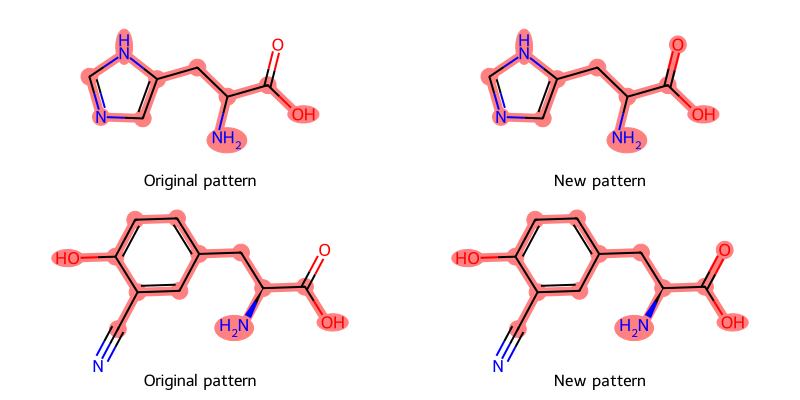

In [93]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from copy import copy
from IPython.display import display
from itertools import chain

def plot_2D_highlight(mol, matches):
    ligand_2d = copy(mol)
    AllChem.Compute2DCoords(ligand_2d)
    matches = list(chain(*matches))
    if len(matches) == 0:
        display(Draw.MolToImage(ligand_2d, size=(400, 200)))
    else:
        display(Draw.MolToImage(ligand_2d, highlightAtoms=matches, size=(400, 200)))

original_pattern = Chem.MolFromSmarts("[#7,#8,P,S,Se,Te,a;!+{1-}][*]")

# new pattern matches not only a single bond in acceptor but any bond other than a triple bond
# probably we would not see nitrile as acceptor, but this pattern now matches carbonyl, which is acceptor in
# many complexes available in the PDB (according to the Auffinger et al. PNAS 2004 paper)

new_pattern = Chem.MolFromSmarts("[#7,#8,P,S,Se,Te,a;!+{1-}]!#[*]")
histidine = Chem.MolFromSmiles("C1=C(NC=N1)CC(C(=O)O)N")
# nitryl is added to the tyrozine just to show that the new pattern does not match it, as well as the original pattern
tyrozine = Chem.MolFromSmiles("C1=C(C#N)C(=CC=C1C[C@@H](C(=O)O)N)O")

original_pattern_matches_his = list(chain(*histidine.GetSubstructMatches(original_pattern)))
new_pattern_matches_his = list(chain(*histidine.GetSubstructMatches(new_pattern)))
original_pattern_matches_tyr = list(chain(*tyrozine.GetSubstructMatches(original_pattern)))
new_pattern_matches_tyr = list(chain(*tyrozine.GetSubstructMatches(new_pattern)))
Draw.MolsToGridImage([histidine, histidine, tyrozine, tyrozine], molsPerRow=2, subImgSize=(400, 200),
                        legends=["Original pattern", "New pattern", "Original pattern", "New pattern"],
                        highlightAtomLists=[original_pattern_matches_his, 
                                            new_pattern_matches_his, original_pattern_matches_tyr, 
                                            new_pattern_matches_tyr])

In [94]:
original_pattern_matches_his

[0, 1, 0, 4, 1, 2, 1, 5, 2, 3, 3, 4, 9, 7, 10, 6]

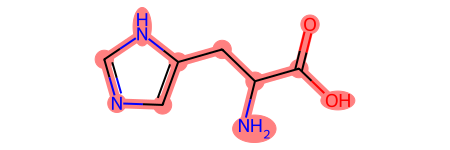

In [95]:
histidine

In [96]:
histidine.GetSubstructMatches(original_pattern)

((0, 1), (0, 4), (1, 2), (1, 5), (2, 3), (3, 4), (9, 7), (10, 6))

In [97]:
from rdkit.Chem import Descriptors
print((Descriptors._descList))

[('MaxAbsEStateIndex', <function MaxAbsEStateIndex at 0x745b31ea8680>), ('MaxEStateIndex', <function MaxEStateIndex at 0x745b31ea8540>), ('MinAbsEStateIndex', <function MinAbsEStateIndex at 0x745b31ea8720>), ('MinEStateIndex', <function MinEStateIndex at 0x745b31ea85e0>), ('qed', <function qed at 0x745b31eab4c0>), ('SPS', <function SPS at 0x745b31eaba60>), ('MolWt', <function <lambda> at 0x745b31eab9c0>), ('HeavyAtomMolWt', <function HeavyAtomMolWt at 0x745b31ecc220>), ('ExactMolWt', <function <lambda> at 0x745b31ecc2c0>), ('NumValenceElectrons', <function NumValenceElectrons at 0x745b31ecc360>), ('NumRadicalElectrons', <function NumRadicalElectrons at 0x745b31ecc400>), ('MaxPartialCharge', <function MaxPartialCharge at 0x745b31ecc540>), ('MinPartialCharge', <function MinPartialCharge at 0x745b31ecc5e0>), ('MaxAbsPartialCharge', <function MaxAbsPartialCharge at 0x745b31ecc680>), ('MinAbsPartialCharge', <function MinAbsPartialCharge at 0x745b31ecc720>), ('FpDensityMorgan1', <function Fp

# 反应点位匹配

In [98]:
import pickle
import pandas as pd
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor
from rdkit.Chem import rdMolDescriptors
from rdkit import RDLogger,Chem
import numpy as np
RDLogger.DisableLog('rdApp.*')

dataset_dir = '../data'   # Change this to your dataset directory

train_df_round1 = pd.read_csv(f'{dataset_dir}/round1_train_data.csv')
train_df_round2 = pd.read_csv(f'{dataset_dir}/round2_train_data.csv')

train_df_round1['rxntype'] = 1

train_df = pd.concat([train_df_round1, train_df_round2])

print(f'Training set size: {len(train_df)}')

grouped = train_df.groupby('rxntype')

# 将拆分后的 DataFrame 存储在一个字典中，键为 rxntype 值，值为对应的 DataFrame
# train_dflist = [group for group in grouped]
train_df_dict = {rxntype: group for rxntype, group in grouped}

Training set size: 96852


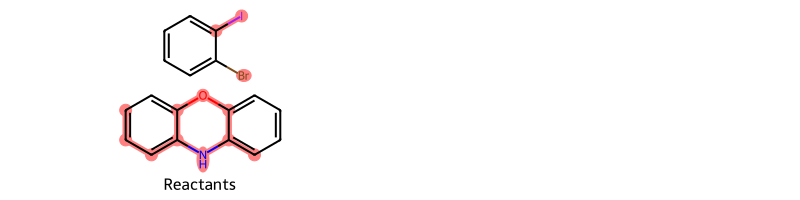

In [99]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.rdchem import BondType
columns=['Reactant1','Reactant2','Product','Additive','Solvent']

reactant1_smiles=train_df_round1.iloc[0].Reactant1
reactant2_smiles=train_df_round1.iloc[0].Reactant2
product_smiles=train_df_round1.iloc[0].Product


# 将SMILES转换为分子对象
reactant1 = Chem.MolFromSmiles(reactant1_smiles)
reactant2 = Chem.MolFromSmiles(reactant2_smiles)
product = Chem.MolFromSmiles(product_smiles)

# 将反应物组合为一个分子（这一步是为了统一比较）
combined_reactants = Chem.CombineMols(reactant1, reactant2)

# 获取键的变化：断裂的键和新形成的键
def get_changed_bonds(mol1, mol2):
    mol1_bonds = {(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(), bond.GetBondType()) for bond in mol1.GetBonds()}
    mol2_bonds = {(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(), bond.GetBondType()) for bond in mol2.GetBonds()}
    
    # 找到断裂的键（出现在反应物中但不在产物中）
    broken_bonds = mol1_bonds - mol2_bonds
    # 找到新形成的键（出现在产物中但不在反应物中）
    formed_bonds = mol2_bonds - mol1_bonds
    return broken_bonds, formed_bonds

# 比较反应物和产物，找出键的变化
broken_bonds, formed_bonds = get_changed_bonds(combined_reactants, product)

# 找到涉及的原子
def get_atoms_from_bonds(bonds):
    atom_indices = set()
    for bond in bonds:
        atom_indices.add(bond[0])
        atom_indices.add(bond[1])
    return list(atom_indices)

# 获取发生反应的原子
reacting_atoms = get_atoms_from_bonds(broken_bonds) + get_atoms_from_bonds(formed_bonds)

# 可视化反应物和产物，显示发生反应的原子
# def draw_molecule_with_highlight(mol, atoms_to_highlight, name):
#     img = Draw.MolsToImage([mol], highlightAtomLists=[atoms_to_highlight], subImgSize=(300, 300))
#     img.show()

# 绘制反应物和产物，并高亮反应位点
# draw_molecule_with_highlight(combined_reactants, reacting_atoms[:], "reactant1")
# draw_molecule_with_highlight(product, reacting_atoms, "product")
# draw_molecule_with_highlight(reactant1, reacting_atoms[:len(reactant1.GetAtoms())], "reactant1")
# draw_molecule_with_highlight(reactant2, reacting_atoms[len(reactant1.GetAtoms()):], "reactant2")
# draw_molecule_with_highlight(product, reacting_atoms, "product")

# Draw.MolsToGridImage([combined_reactants,product], molsPerRow=2, subImgSize=(400, 200),
#                         legends=["Reactants","product"],
#                         highlightAtomLists=[reacting_atoms,reacting_atoms])

Draw.MolsToGridImage([combined_reactants], molsPerRow=2, subImgSize=(400, 200),
                        legends=["Reactants"],
                        highlightAtomLists=[reacting_atoms])

In [100]:
mol1=combined_reactants
mol2=product

mol1_bonds = {(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(), bond.GetBondType()) for bond in mol1.GetBonds()}
mol2_bonds = {(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(), bond.GetBondType()) for bond in mol2.GetBonds()}

# 找到断裂的键（出现在反应物中但不在产物中）
broken_bonds = mol1_bonds - mol2_bonds
# 找到新形成的键（出现在产物中但不在反应物中）
formed_bonds = mol2_bonds - mol1_bonds


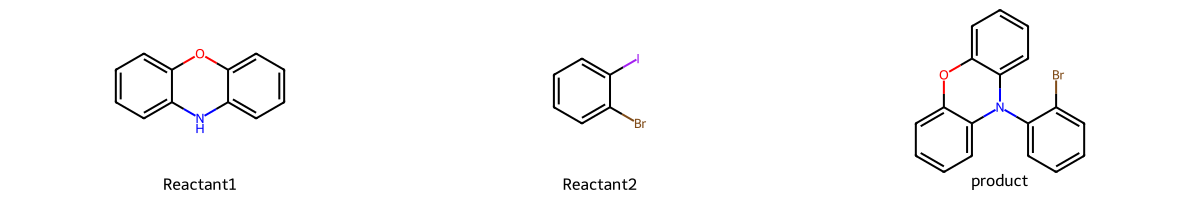

In [101]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.rdchem import BondType
columns=['Reactant1','Reactant2','Product','Additive','Solvent']

reactant1_smiles=train_df_round1.iloc[0].Reactant1
reactant2_smiles=train_df_round1.iloc[0].Reactant2
product_smiles=train_df_round1.iloc[0].Product


# 将SMILES转换为分子对象
reactant1 = Chem.MolFromSmiles(reactant1_smiles)
reactant2 = Chem.MolFromSmiles(reactant2_smiles)
product = Chem.MolFromSmiles(product_smiles)


Draw.MolsToGridImage([reactant1,reactant2,product], molsPerRow=3, subImgSize=(400, 200),
                        legends=["Reactant1","Reactant2","product"],
                    )

反应物1（溴苯）中的卤素原子索引: [0, 7]
反应物2（甲胺）中的氨基原子索引: [6]
断裂的键: {((15, 25), rdkit.Chem.rdchem.BondType.SINGLE), ((12, 26), rdkit.Chem.rdchem.BondType.SINGLE), ((22, 33), rdkit.Chem.rdchem.BondType.SINGLE), ((5, 11), rdkit.Chem.rdchem.BondType.SINGLE), ((21, 22), rdkit.Chem.rdchem.BondType.AROMATIC), ((13, 14), rdkit.Chem.rdchem.BondType.AROMATIC), ((19, 24), rdkit.Chem.rdchem.BondType.AROMATIC), ((14, 28), rdkit.Chem.rdchem.BondType.SINGLE), ((18, 30), rdkit.Chem.rdchem.BondType.SINGLE), ((24, 25), rdkit.Chem.rdchem.BondType.SINGLE), ((4, 10), rdkit.Chem.rdchem.BondType.SINGLE), ((18, 19), rdkit.Chem.rdchem.BondType.SINGLE), ((21, 32), rdkit.Chem.rdchem.BondType.SINGLE), ((20, 21), rdkit.Chem.rdchem.BondType.AROMATIC), ((20, 31), rdkit.Chem.rdchem.BondType.SINGLE), ((23, 34), rdkit.Chem.rdchem.BondType.SINGLE), ((23, 24), rdkit.Chem.rdchem.BondType.AROMATIC), ((14, 15), rdkit.Chem.rdchem.BondType.AROMATIC), ((12, 17), rdkit.Chem.rdchem.BondType.AROMATIC), ((13, 27), rdkit.Chem.rdchem.BondType.SIN

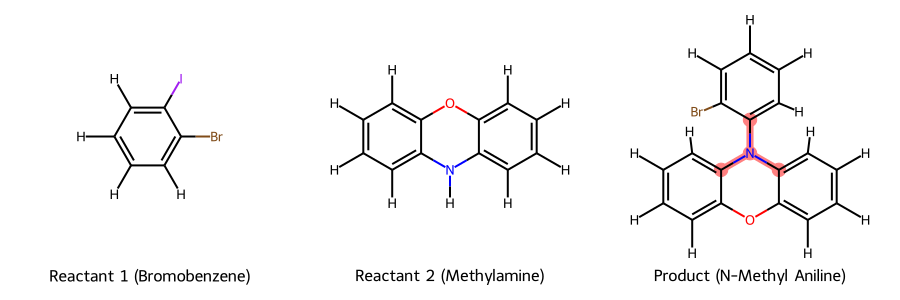

In [102]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.rdchem import BondType

def get_halogen_atoms(mol):
    """
    获取分子中的所有卤素原子（F, Cl, Br, I）。
    """
    return [atom.GetIdx() for atom in mol.GetAtoms() if atom.GetAtomicNum() in [9, 17, 35, 53]]

def get_amino_atoms(mol):
    """
    获取分子中的氨基原子（氮原子，且至少有一个氢原子相连）。
    """
    amino_atoms = []
    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 7:
            # 检查氮原子是否至少与一个氢原子相连
            if any(neigh.GetAtomicNum() == 1 for neigh in atom.GetNeighbors()):
                amino_atoms.append(atom.GetIdx())
    return amino_atoms

def get_bond_set(mol):
    """
    获取分子的所有键，作为集合返回，每个键表示为((原子1, 原子2), 键类型)。
    """
    bonds = set()
    for bond in mol.GetBonds():
        a1 = bond.GetBeginAtomIdx()
        a2 = bond.GetEndAtomIdx()
        bond_type = bond.GetBondType()
        bonds.add(((min(a1, a2), max(a1, a2)), bond_type))
    return bonds

def find_changed_bonds(reactant1, reactant2, product):
    """
    比较反应物和产物，找出断裂的键和新形成的键。
    """
    # 将反应物1和反应物2合并为一个分子
    combined_reactants = Chem.CombineMols(reactant1, reactant2)
    reactant_bonds = get_bond_set(combined_reactants)
    product_bonds = get_bond_set(product)
    
    # 断裂的键：存在于反应物中但不存在于产物中
    broken_bonds = reactant_bonds - product_bonds
    # 新形成的键：存在于产物中但不存在于反应物中
    formed_bonds = product_bonds - reactant_bonds
    return broken_bonds, formed_bonds

def get_atoms_from_bonds(bonds):
    """
    从键集合中提取所有涉及的原子索引。
    """
    atoms = set()
    for bond in bonds:
        atoms.update(bond[0])
    return list(atoms)

# 定义反应物和产物的SMILES（以Buchwald-Hartwig反应为例）
# reactant1_smiles = "C1=CC=CC=C1Br"  # 溴苯
# reactant2_smiles = "CN"             # 甲胺
# product_smiles = "C1=CC=CC=C1NC"    # N-甲基苯胺

reactant2_smiles=train_df_round1.iloc[0].Reactant1
reactant1_smiles=train_df_round1.iloc[0].Reactant2
product_smiles=train_df_round1.iloc[0].Product

# 将SMILES转换为RDKit分子对象
reactant1 = Chem.MolFromSmiles(reactant1_smiles)
reactant2 = Chem.MolFromSmiles(reactant2_smiles)
reactant1=Chem.AddHs(reactant1)
reactant2=Chem.AddHs(reactant2)
product = Chem.MolFromSmiles(product_smiles)
product=Chem.AddHs(product)


# 找出反应物中的卤素和氨基原子
reactant1_halogens = get_halogen_atoms(reactant1)
reactant2_amino = get_amino_atoms(reactant2)

print(f"反应物1（溴苯）中的卤素原子索引: {reactant1_halogens}")
print(f"反应物2（甲胺）中的氨基原子索引: {reactant2_amino}")

# 找出断裂的键和新形成的键
broken_bonds, formed_bonds = find_changed_bonds(reactant1, reactant2, product)
print(f"断裂的键: {broken_bonds}")
print(f"新形成的键: {formed_bonds}")

# 提取断裂和形成键涉及的原子
broken_atoms = get_atoms_from_bonds(broken_bonds)
formed_atoms = get_atoms_from_bonds(formed_bonds)

# 找出参与反应的卤素原子（断裂键中的卤素）
reacting_halogens = [atom for atom in reactant1_halogens if atom in broken_atoms]
print(f"参与反应的卤素原子索引: {reacting_halogens}")

# 找出参与反应的氨基原子（形成键中的氮原子）
reacting_amino = [atom for atom in reactant2_amino if atom in formed_atoms]
print(f"参与反应的氨基原子索引: {reacting_amino}")

# 在产物中找出新形成的C-N键涉及的原子
# 假设新的C-N键连接了溴苯中的碳和甲胺中的氮
product_nitrogens = [atom.GetIdx() for atom in product.GetAtoms() if atom.GetAtomicNum() == 7]
product_reacting_carbons = []
for n in product_nitrogens:
    for neighbor in product.GetAtomWithIdx(n).GetNeighbors():
        if neighbor.GetAtomicNum() == 6:
            product_reacting_carbons.append(neighbor.GetIdx())
product_reacting_carbons = list(set(product_reacting_carbons))
print(f"产物中参与反应的碳原子索引: {product_reacting_carbons}")

# 定义高亮显示的原子
highlight_reactant1 = reacting_halogens
highlight_reactant2 = reacting_amino
highlight_product = product_nitrogens + product_reacting_carbons

# 打印高亮原子信息
print(f"高亮反应物1中的卤素原子: {highlight_reactant1}")
print(f"高亮反应物2中的氨基原子: {highlight_reactant2}")
print(f"高亮产物中的反应位点原子: {highlight_product}")

# 可视化分子并高亮反应位点
mols = [reactant1, reactant2, product]
highlight_atom_lists = [highlight_reactant1, highlight_reactant2, highlight_product]

# 使用 MolsToGridImage 绘制分子网格图，突出高亮原子
img = Draw.MolsToGridImage(
    mols,
    highlightAtomLists=highlight_atom_lists,
    molsPerRow=3,
    subImgSize=(300, 300),
    legends=["Reactant 1 (Bromobenzene)", "Reactant 2 (Methylamine)", "Product (N-Methyl Aniline)"]
)

img

## 公共函数

### 可视化反应位点

断裂的键: []
新形成的键: [(1, 23), (24, 3)]


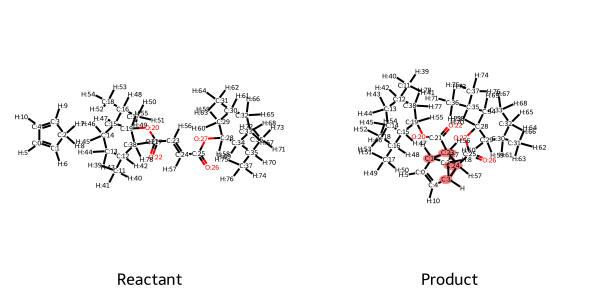

In [103]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
from PIL import Image 
from io import BytesIO

def parse_smiles_with_mapping(smiles):
    """
    将带有原子映射的 SMILES 转换为 RDKit 分子对象，并保留原子映射。
    """
    ps = Chem.SmilesParserParams()
    ps.removeHs = False
    mol = Chem.MolFromSmiles(smiles,ps)
    mol = Chem.AddHs(mol)
    if mol is None:
        raise ValueError(f"无法解析 SMILES: {smiles}")
    
    return mol

def get_mapped_atoms(mol):
    """
    提取分子中带有映射的原子，返回映射编号和原子索引的对应关系。
    """
    atom_map = {}
    for atom in mol.GetAtoms():
        map_num = atom.GetAtomMapNum()
        if map_num >= 0:  # 只考虑有映射的原子
            atom_map[map_num] = atom.GetIdx()
    return atom_map

def find_changed_bonds(reactant_mol, product_mol, reactant_map, product_map):
    """
    比较反应物和产物中的键，找到断裂的键和新形成的键。
    针对 N-H 和 C-I 键的变化做特殊处理。
    """
    changed_bonds = {"broken": [], "formed": []}
    
    # 遍历反应物中的键，寻找断裂的键
    for bond in reactant_mol.GetBonds():
        a1_map = reactant_mol.GetAtomWithIdx(bond.GetBeginAtomIdx()).GetAtomMapNum()
        a2_map = reactant_mol.GetAtomWithIdx(bond.GetEndAtomIdx()).GetAtomMapNum()
        
        if a1_map > 0 and a2_map > 0 and (a1_map in product_map) and (a2_map in product_map):
            # 检查反应物中的键在产物中是否存在
            bond_in_product = product_mol.GetBondBetweenAtoms(product_map[a1_map], product_map[a2_map])
            if bond_in_product is None:
                changed_bonds["broken"].append((a1_map, a2_map))
    
    # 遍历产物中的键，寻找新形成的键
    for bond in product_mol.GetBonds():
        a1_map = product_mol.GetAtomWithIdx(bond.GetBeginAtomIdx()).GetAtomMapNum()
        a2_map = product_mol.GetAtomWithIdx(bond.GetEndAtomIdx()).GetAtomMapNum()
        
        if a1_map > 0 and a2_map > 0 and (a1_map in reactant_map) and (a2_map in reactant_map):
            # 检查产物中的键在反应物中是否存在
            bond_in_reactant = reactant_mol.GetBondBetweenAtoms(reactant_map[a1_map], reactant_map[a2_map])
            if bond_in_reactant is None:
                changed_bonds["formed"].append((a1_map, a2_map))
    
    # 处理特殊情况：C-I 和 N-H 键的变化
    for atom in reactant_mol.GetAtoms():
        map_num = atom.GetAtomMapNum()
        if map_num > 0 and map_num in product_map:
            # 针对氮原子：检查 N-H 键的断裂
            if atom.GetAtomicNum() == 7:  # 氮原子
                # 查找反应物中的氢键（N-H 键）
                reactant_H_neighbors = [n.GetAtomMapNum() for n in atom.GetNeighbors() if n.GetAtomicNum() == 1]
                product_H_neighbors = [n.GetAtomMapNum() for n in product_mol.GetAtomWithIdx(product_map[map_num]).GetNeighbors() if n.GetAtomicNum() == 1]
                for h in reactant_H_neighbors:
                    if h not in product_H_neighbors:
                        changed_bonds["broken"].append((map_num, h))
                        # print(map_num,h)
                        
            # 针对碳碘键：检查 C-I 键的断裂
            if atom.GetAtomicNum() == 6:  # 碳原子
                reactant_I_neighbors = [n.GetAtomMapNum() for n in atom.GetNeighbors() if n.GetAtomicNum() == 53]
                product_I_neighbors = [n.GetAtomMapNum() for n in product_mol.GetAtomWithIdx(product_map[map_num]).GetNeighbors() if n.GetAtomicNum() == 53]
                for i in reactant_I_neighbors:
                    if i not in product_I_neighbors:
                        changed_bonds["broken"].append((map_num, i))

                reactant_I_neighbors = [n.GetAtomMapNum() for n in atom.GetNeighbors() if n.GetAtomicNum() == 35]
                product_I_neighbors = [n.GetAtomMapNum() for n in product_mol.GetAtomWithIdx(product_map[map_num]).GetNeighbors() if n.GetAtomicNum() == 35]
                for i in reactant_I_neighbors:
                    if i not in product_I_neighbors:
                        changed_bonds["broken"].append((map_num, i))
                        # print("I",map_num,i)
                        
    
    return changed_bonds

def visualize_reaction(reactant_mol, product_mol, changed_bonds, reactant_map, product_map):
    """
    可视化反应物和产物，并高亮显示反应位点。
    """
    # 高亮的原子列表
    highlight_atoms = {"reactant": [], "product": []}
    
    # 添加变化的原子
    for bond in changed_bonds["broken"]:
        highlight_atoms["reactant"].extend([reactant_map[bond[0]], reactant_map[bond[1]]])
    
    for bond in changed_bonds["formed"]:
        highlight_atoms["product"].extend([product_map[bond[0]], product_map[bond[1]]])
    
    mols = [reactant_mol, product_mol]
    highlight_lists = [highlight_atoms["reactant"], highlight_atoms["product"]]
    
    # 使用 RDKit 的 MolsToGridImage 进行可视化
    img = Draw.MolsToGridImage(
        mols,
        highlightAtomLists=highlight_lists,
        molsPerRow=2,
        subImgSize=(300, 300),
        legends=["Reactant", "Product"]
    )
    return img

for smi in pred_smi[::1000]:
    # 提供的反应物和产物 SMILES，包含 atom mapping
    tmpsmi=smi.split(">>")
    reactant_smiles=tmpsmi[0][1:-1]
    product_smiles=tmpsmi[1]    
    # 解析 SMILES
    reactant_mol = parse_smiles_with_mapping(reactant_smiles)
    product_mol = parse_smiles_with_mapping(product_smiles)
    
    # 提取原子映射信息
    reactant_map = get_mapped_atoms(reactant_mol)
    product_map = get_mapped_atoms(product_mol)
    
    # 找到键的变化
    changed_bonds = find_changed_bonds(reactant_mol, product_mol, reactant_map, product_map)
    
    print(f"断裂的键: {changed_bonds['broken']}")
    print(f"新形成的键: {changed_bonds['formed']}")
    
    # 可视化反应并高亮反应位点
    img=visualize_reaction(reactant_mol, product_mol, changed_bonds, reactant_map, product_map)
    im = Image.open(BytesIO(img.data))
    display(im)

### make_rxns

In [104]:
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from copy import copy
from IPython.display import display
from itertools import chain

def visualize_reaction(reactant_mol, product_mol):    
    mols = [reactant_mol, product_mol]    
    # 使用 RDKit 的 MolsToGridImage 进行可视化
    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=2,
        subImgSize=(500, 500),
        legends=["Reactant", "Product"]
    )
    return img
    
def make_rxns(source_rxn, reactants):
    product_sets = source_rxn.RunReactants(reactants)
    new_rxns = []
    for pset in product_sets:
        new_rxn = AllChem.ChemicalReaction()
        for react in reactants:
            react = Chem.Mol(react)
            for a in react.GetAtoms():
                a.SetIntProp('molAtomMapNumber', a.GetIdx())
            new_rxn.AddReactantTemplate(react)
        for prod in pset:
            for a in prod.GetAtoms():
                a.SetIntProp('molAtomMapNumber', int(a.GetProp('react_atom_idx')))
            new_rxn.AddProductTemplate(prod)
        new_rxns.append(new_rxn)
    return new_rxns

### clean_smi

In [105]:
from rdkit import Chem

def remove_atom_mapping(smiles):
    """
    移除 SMILES 中的原子映射并返回新的 SMILES。
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"无法解析 SMILES: {smiles}")
    
    # 遍历分子的所有原子，清除 AtomMapNum
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(0)
    
    # 生成没有原子映射的 SMILES
    new_smiles = Chem.MolToSmiles(mol)
    return new_smiles

def clean_smi(smi):
    # 提供的反应物和产物 SMILES，包含 atom mapping
    tmpsmi=smi.split(">>")
    reactant_smiles=tmpsmi[0][1:-1]
    product_smiles=tmpsmi[1] 

    # 移除 atom mapping
    smiles_no_mapping = remove_atom_mapping(product_smiles)
    
    # print(f"带有 atom mapping 的 SMILES: {product_smiles}")
    return smiles_no_mapping


## RXN1

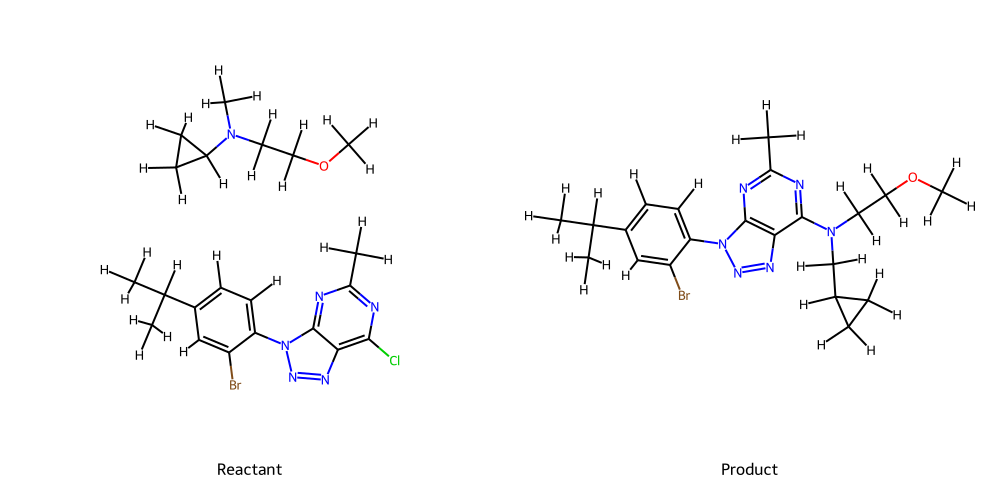

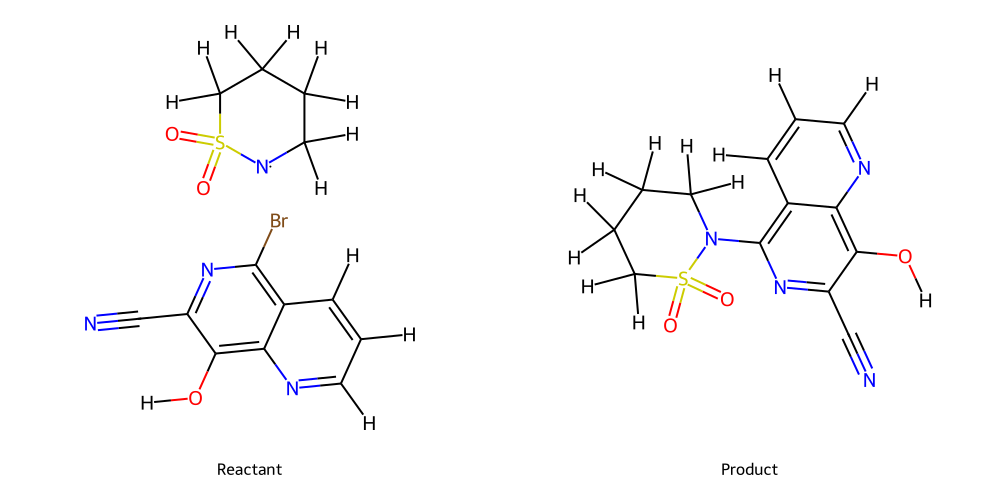

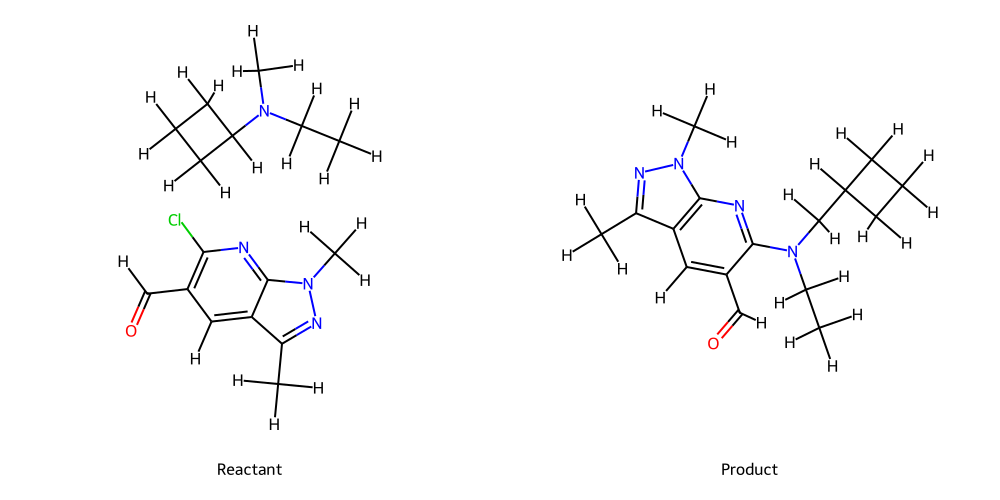

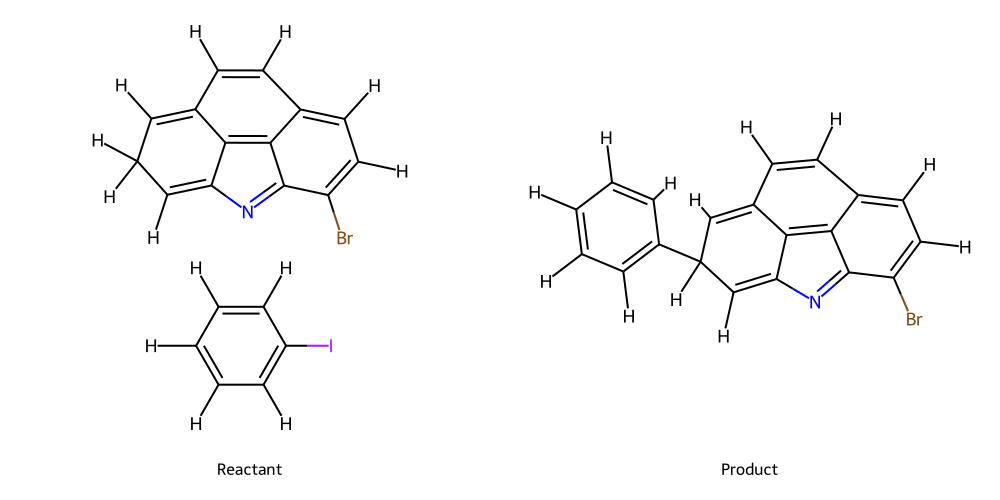

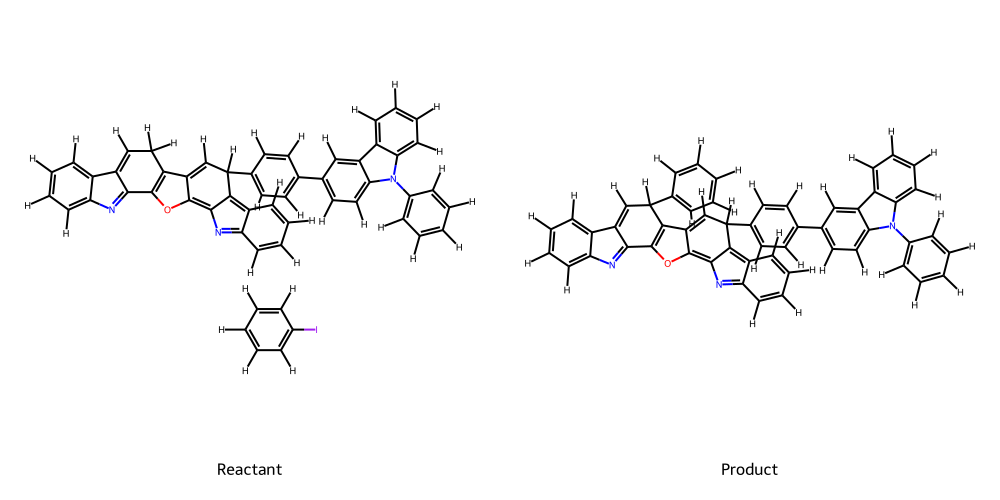

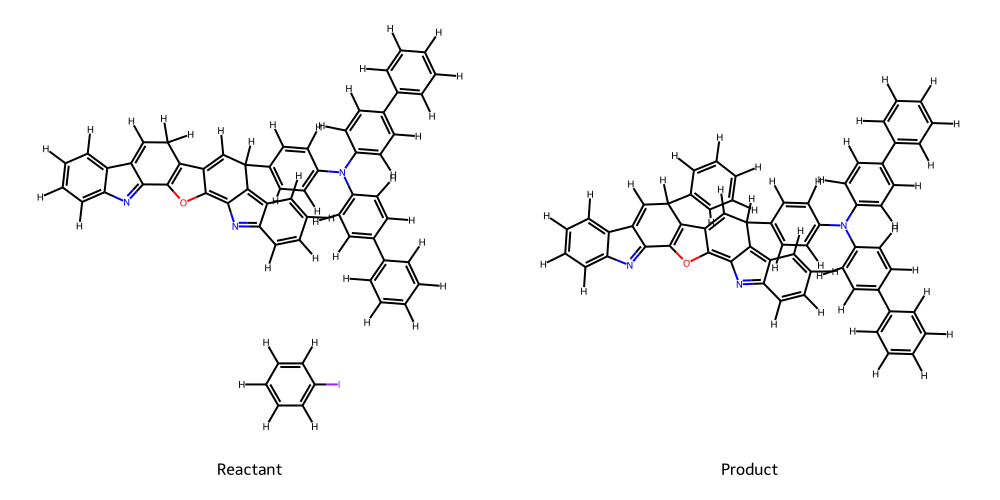

In [106]:
pred_smi=[]

ps = Chem.SmilesParserParams()
ps.removeHs = False

match_count=0
unmatch_count=0
err_count=0

bh_reaction_smarts = [
                    "([c,C:1][I,Br,F,Cl].[N,n:2][H:4])>>[C:1][N:2]",
                    "([c,C:1][I,Br,F,Cl].[S,s:2][H:4])>>[C:1][N:2]"
                     ]

rxn_match_count=[0 for i in range(len(bh_reaction_smarts))]

irxn=1
train_df=train_df_dict[irxn]
for i in range(len(train_df)):
# for i in range(100):
    reactant1_smiles=train_df.iloc[i].Reactant2
    reactant2_smiles=train_df.iloc[i].Reactant1
    product_smiles=train_df.iloc[i].Product
    
    reactant1 = Chem.MolFromSmiles(reactant1_smiles,ps)
    reactant2 = Chem.MolFromSmiles(reactant2_smiles,ps)
    product = Chem.MolFromSmiles(product_smiles,ps)
    reactant1=Chem.AddHs(reactant1)
    reactant2=Chem.AddHs(reactant2)
    product=Chem.AddHs(product)
    
    rmol = Chem.CombineMols(reactant1,reactant2)    
    
    reactions = [AllChem.ReactionFromSmarts(bh_reaction_smarts[i]) for i in range(len(bh_reaction_smarts))]

    # pattern1_smiles="F[B-](F)(F)F"
    # sub_mol=Chem.MolFromSmiles(pattern1_smiles)

    # if rmol.GetSubstructMatches(sub_mol):
    #     # count+=1
    #     continue
        
    revert=False
    
    match=False
    for j,reaction in enumerate(reactions):
        try:
            if len(make_rxns(reaction, [rmol]))==0:
                rmol2 = Chem.CombineMols(reactant2,reactant1)
                if len(make_rxns(reaction, [rmol2]))==0:
                    continue
                else:
                    revert=True
                    match=True
            else:
                match=True
            if match: rxn_match_count[j]+=1
            if not revert:
                check=rmol
            else:
                check=rmol2
            for r in make_rxns(reaction, [check]):
                smi = AllChem.ReactionToSmiles(r)
                pred_smi.append(smi)
        except:
            err_count+=1
            print("Error",reactant1_smiles,reactant2_smiles,product_smiles)
    if match:
        match_count+=1
    else:
        unmatch_count+=1

    if not match:
        img=visualize_reaction(rmol, product)
        im = Image.open(BytesIO(img.data))
        display(im)
    # print(reactant1_smiles,reactant2_smiles,product_smiles)
    # try:
    #     print("clean_smi",clean_smi(smi))
    # except:
    #     err_count+=1
    #     print("Error",smi)

In [107]:
match_count,unmatch_count

(23532, 6)

In [108]:
# pattern1='[c,C:1][I,Br,F,Cl]'
# pattern2='[N,n:2][H:4]'
# # pattern2='NH'

# patten_mol= Chem.MolFromSmarts(pattern2)
# rmol2.GetSubstructMatches(patten_mol)

## RXN 2

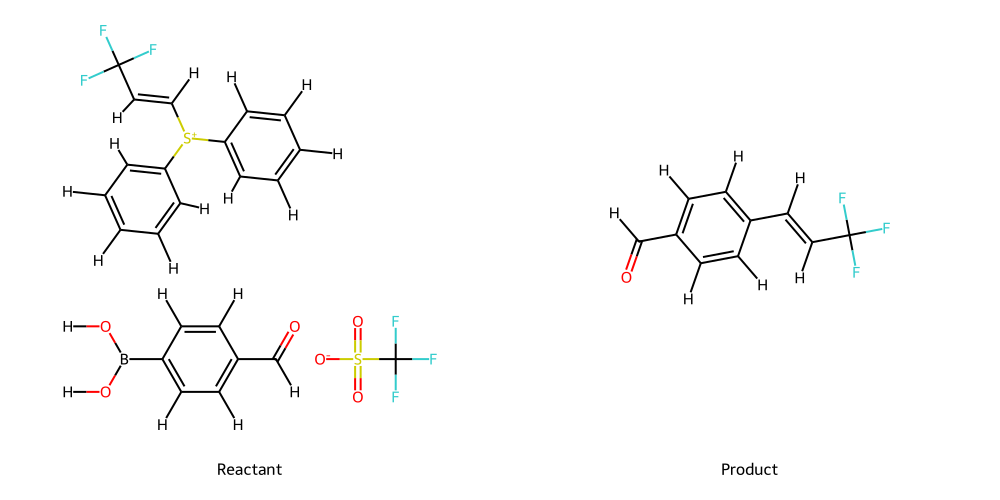

No. 482 Samples O=Cc1ccc(B(O)O)cc1 FC(F)(F)/C=C/[S+](c1ccccc1)c1ccccc1.O=S(=O)([O-])C(F)(F)F O=Cc1ccc(/C=C/C(F)(F)F)cc1


In [109]:
pred_smi=[]

ps = Chem.SmilesParserParams()
ps.removeHs = False

match_count=0
unmatch_count=0
err_count=0

bh_reaction_smarts = [
                    # "([c,C:1][Br,I,Cl].[c,C:2][B:3]([OH,OR])([OH,OR]))>>[c,C:1][c,C:2]",
                    "([c,C:1][O,o][S].[c,C:2][B:3]([O,F])([O,F]))>>[c,C:1][c,C:2]",
                    "([c,C:1][Br,I,Cl].[c,C:2][B:3]([O,o,N,n,F,C,c])([O,o,N,n,F,C,c]))>>[c,C:1][c,C:2]",
                    "([C,c:1][C,c:2](=[O])[O].[C,c:3][B])>>[C:1][C:3]",
                    "([C,c:1](=[O:2])[N,n].[C,c:3][B])>>[C:1](=[O:2])[C:3]"
                     ]

rxn_match_count=[0 for i in range(len(bh_reaction_smarts))]

irxn=2
train_df=train_df_dict[irxn]
skip={20,267,285,330,366,447}
for i in range(len(train_df)):
# for i in range(100):
    if i in skip: continue
    reactant1_smiles=train_df.iloc[i].Reactant2
    reactant2_smiles=train_df.iloc[i].Reactant1
    product_smiles=train_df.iloc[i].Product
    
    reactant1 = Chem.MolFromSmiles(reactant1_smiles,ps)
    reactant2 = Chem.MolFromSmiles(reactant2_smiles,ps)
    product = Chem.MolFromSmiles(product_smiles,ps)
    reactant1=Chem.AddHs(reactant1)
    reactant2=Chem.AddHs(reactant2)
    product=Chem.AddHs(product)
    
    rmol = Chem.CombineMols(reactant1,reactant2)    
    
    reactions = [AllChem.ReactionFromSmarts(bh_reaction_smarts[i]) for i in range(len(bh_reaction_smarts))]

    # pattern1_smiles="F[B-](F)(F)F"
    # sub_mol=Chem.MolFromSmiles(pattern1_smiles)

    # if rmol.GetSubstructMatches(sub_mol):
    #     # count+=1
    #     continue
        
    revert=False    
    match=False
    for j,reaction in enumerate(reactions):
        try:
            if len(make_rxns(reaction, [rmol]))==0:
                rmol2 = Chem.CombineMols(reactant2,reactant1)
                if len(make_rxns(reaction, [rmol2]))==0:
                    continue
                else:
                    revert=True
                    match=True
            else:
                match=True
            if match: rxn_match_count[j]+=1
            if not revert:
                check=rmol
            else:
                check=rmol2
            for r in make_rxns(reaction, [check]):
                smi = AllChem.ReactionToSmiles(r)
                pred_smi.append(smi)
        except:
            err_count+=1
            # print("Error",reactant1_smiles,reactant2_smiles,product_smiles)
    if match:
        match_count+=1
    else:
        unmatch_count+=1

    if not match:
        img=visualize_reaction(rmol, product)
        im = Image.open(BytesIO(img.data))
        display(im)
        print(f"No. {i} Samples",reactant1_smiles,reactant2_smiles,product_smiles)
        break
    # try:
    #     print("clean_smi",clean_smi(smi))
    # except:
    #     err_count+=1
    #     print("Error",smi)

In [110]:
match_count,unmatch_count,err_count

(476, 1, 0)

In [111]:
bh_reaction_smarts = [
                    "([c,C:1][O,o][S].[c,C:2][B:3]([O,F])([O,F]))>>[c,C:1][c,C:2]",
                    # "([c,C:1][Br,I,Cl].[c,C:2][B:3]([O,o,N,n,F,C,c])([O,o,N,n,F,C,c]))>>[c,C:1][c,C:2]",
                    # "([C,c:1][C,c:2](=[O])[O].[C,c:3][B])>>[C:1][C:3]",
                    # "([C,c:1](=[O:2])[N].[C,c:3][B])>>[C:1](=[O:2])[C:3]",
                     ]

patterns=bh_reaction_smarts[0].split(">>")
pattern1=patterns[0][1:-1].split('.')[0]
pattern2=patterns[0][1:-1].split('.')[1]
patten_mol1= Chem.MolFromSmarts(pattern1)
patten_mol2= Chem.MolFromSmarts(pattern2)

print(pattern1,rmol.GetSubstructMatches(patten_mol1))
print(pattern2,rmol.GetSubstructMatches(patten_mol2))

rmol = Chem.CombineMols(reactant1,reactant2)
reactions = [AllChem.ReactionFromSmarts(bh_reaction_smarts[i]) for i in range(len(bh_reaction_smarts))]
for reaction in reactions:
    for r in make_rxns(reaction, [rmol]):
        smi = AllChem.ReactionToSmiles(r)
        print("pred product",clean_smi(smi))
print(product_smiles)

[c,C:1][O,o][S] ()
[c,C:2][B:3]([O,F])([O,F]) ((5, 6, 7, 8),)
O=Cc1ccc(/C=C/C(F)(F)F)cc1


## RXN3

In [112]:
pred_smi=[]

ps = Chem.SmilesParserParams()
ps.removeHs = False

match_count=0
unmatch_count=0
err_count=0

bh_reaction_smarts = [
                        "([c,C:1][Br,I,Cl].[R;r5:2][H])>>[c,C:1][R;r5:2]",                                                                    
                        "([C,c:1][C,c](=[O,o])[O,o].[C,c:2]=[C,c:3]([H])[H:4])>>[C:1][C:3]([H:4])=[C:2]",
                        "([C,c:1][N,n]#[N,n].[C,c:2]=[C,c:3][H])>>[C:2]=[C:3][C:1]",    
                        "([C,c:1]=[C,c:2][H].[C,c:3][Br,I,F,Cl:4])>>[C:1]=[C:2][c:3]",
                        "([C,c:1](=[O,o:2])[H].[C,c:3][Br,I,F:4])>>[C:1](=[O,o:2])[c:3]"
                    ]

rxn_match_count=[0 for i in range(len(bh_reaction_smarts))]

irxn=3
train_df=train_df_dict[irxn]
# skip={62,66,103,136}
for i in range(len(train_df)):
# for i in range(100):
    if i in skip: continue
    reactant1_smiles=train_df.iloc[i].Reactant2
    reactant2_smiles=train_df.iloc[i].Reactant1
    product_smiles=train_df.iloc[i].Product
    
    reactant1 = Chem.MolFromSmiles(reactant1_smiles,ps)
    reactant2 = Chem.MolFromSmiles(reactant2_smiles,ps)
    product = Chem.MolFromSmiles(product_smiles,ps)
    reactant1=Chem.AddHs(reactant1)
    reactant2=Chem.AddHs(reactant2)
    product=Chem.AddHs(product)
    
    rmol = Chem.CombineMols(reactant1,reactant2)    
    
    reactions = [AllChem.ReactionFromSmarts(bh_reaction_smarts[i]) for i in range(len(bh_reaction_smarts))]

    # pattern1_smiles="F[B-](F)(F)F"
    # sub_mol=Chem.MolFromSmiles(pattern1_smiles)

    # if rmol.GetSubstructMatches(sub_mol):
    #     # count+=1
    #     continue
        
    revert=False    
    match=False
    for j,reaction in enumerate(reactions):
        try:
            Chem.SanitizeMol(rmol)            
            if len(make_rxns(reaction, [rmol]))==0:
                rmol2 = Chem.CombineMols(reactant2,reactant1)
                Chem.SanitizeMol(rmol2)                
                if len(make_rxns(reaction, [rmol2]))==0:
                    continue
                else:
                    revert=True
                    match=True
            else:
                match=True
            if match: rxn_match_count[j]+=1
            if not revert:
                check=rmol
            else:
                check=rmol2
            for r in make_rxns(reaction, [check]):
                smi = AllChem.ReactionToSmiles(r)
                pred_smi.append(smi)
        except:
            err_count+=1
            img=visualize_reaction(rmol, product)
            im = Image.open(BytesIO(img.data))
            display(im)
            print(f"ERROR No. {i} Samples",reactant1_smiles,reactant2_smiles,product_smiles)
            break
    if match:
        match_count+=1
    else:
        unmatch_count+=1

    # if not match:
    #     img=visualize_reaction(rmol, product)
    #     im = Image.open(BytesIO(img.data))
    #     display(im)
    #     print(f"No. {i} Samples",reactant1_smiles,reactant2_smiles,product_smiles)
    #     break
    # try:
    #     print("clean_smi",clean_smi(smi))
    # except:
    #     err_count+=1
    #     print("Error",smi)

In [113]:
print(err_count,match_count,unmatch_count)
print(rxn_match_count)

0 5288 129
[991, 753, 529, 4785, 322]


In [114]:
bh_reaction_smarts = [
                        "([c,C:1][Br,I,Cl].[R;r5:2][H])>>[c,C:1][R;r5:2]",                                            
                        "([C,c:1][C,c](=[O,o])[O,o].[C,c:2]=[C,c:3]([H])[H:4])>>[C:1][C:3]([H:4])=[C:2]",
                        "([C,c:1][N,n]#[N,n].[C,c:2]=[C,c:3][H])>>[C:2]=[C:3][C:1]",
                        "([C,c:1]=[C,c:2][H].[C,c:3][Br,I,Cl,F:4])>>[C:1]=[C:2][c:3]",
                        "([C,c:1](=[O,o:2])[H].[C,c:3][Br,I,Cl,F:4])>>[C:1](=[O,o:2])[c:3]"
                    ]

patterns=bh_reaction_smarts[3].split(">>")
pattern1=patterns[0][1:-1].split('.')[0]
pattern2=patterns[0][1:-1].split('.')[1]
patten_mol1= Chem.MolFromSmarts(pattern1)
patten_mol2= Chem.MolFromSmarts(pattern2)

print(pattern1,rmol.GetSubstructMatches(patten_mol1))
print(pattern2,rmol.GetSubstructMatches(patten_mol2))

rmol = Chem.CombineMols(reactant1,reactant2)
Chem.SanitizeMol(rmol)

reactions = [AllChem.ReactionFromSmarts(bh_reaction_smarts[i]) for i in range(len(bh_reaction_smarts))]
for reaction in reactions:
    for r in make_rxns(reaction, [rmol]):
        smi = AllChem.ReactionToSmiles(r)
        print("pred product",clean_smi(smi))
print(product_smiles)

[C,c:1]=[C,c:2][H] ((0, 1, 9), (1, 0, 7), (1, 0, 8))
[C,c:3][Br,I,Cl,F:4] ((19, 20), (23, 24))
pred product C=C(C(=O)OCC)c1ccc(Br)c(C=O)c1
pred product C=C(C(=O)OCC)c1ccc(Cl)cc1C=O
pred product CCOC(=O)C=Cc1ccc(Br)c(C=O)c1
pred product CCOC(=O)C=Cc1ccc(Cl)cc1C=O
pred product CCOC(=O)C=Cc1ccc(Br)c(C=O)c1
pred product CCOC(=O)C=Cc1ccc(Cl)cc1C=O
pred product O=C1c2ccc(Br)c1c2
pred product O=c1c2ccc(Cl)cc12
CCOC(=O)/C=C/c1ccc(Cl)cc1C=O


In [115]:
patten_mol2= Chem.MolFromSmarts(pattern2)
print(pattern2)
Chem.SanitizeMol(rmol)
rmol.GetSubstructMatches(patten_mol2)

[C,c:3][Br,I,Cl,F:4]


((19, 20), (23, 24))

In [116]:
#Chem.MolFromSmarts(smarts)

In [117]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

# 创建分子对象
mol = Chem.MolFromSmiles("C1CCCC1")  # 这里以环己烷为例
mol = Chem.AddHs(mol)

# 匹配五元环上的碳原子
smarts = "[C;r5:2][H]"
substruct_matches = mol.GetSubstructMatches(Chem.MolFromSmarts(smarts))

print(substruct_matches)

((0, 5), (0, 6), (1, 7), (1, 8), (2, 9), (2, 10), (3, 11), (3, 12), (4, 13), (4, 14))


#### 类型一，含有F[B-](F)(F)F结构，顺反异构

反应中有 F[B-](F)(F)F 结构的为15个,15/100  
C=CC(=O)OC F[B-](F)(F)F.N#[N+]c1ccc(C(F)(F)F)cc1[N+](=O)[O-] COC(=O)/C=C/c1ccc(C(F)(F)F)cc1[N+](=O)[O-]  
C-N#N与C=CH中C-N断裂，CH断裂，C-C相连

#### 类型二 C-Br，卤素被取代，与C=CH键上其中一个C连接

#### 类型三

In [118]:
#C=Cc1ccc2ccccc2c1 Cc1ccc2c(Cl)c(C(=O)O)sc2c1 Cc1ccc2c(Cl)c(/C=C/c3ccc4ccccc4c3)sc2c1
#CCCCCC=O Brc1ccccc1 CCCCCC(=O)c1ccccc1
#CCOC(=O)c1coc(-c2ccc(OC)cc2)n1 O=[N+]([O-])c1ccccc1I CCOC(=O)c1nc(-c2ccc(OC)cc2)oc1-c1ccccc1[N+](=O)[O-]

## RXN4

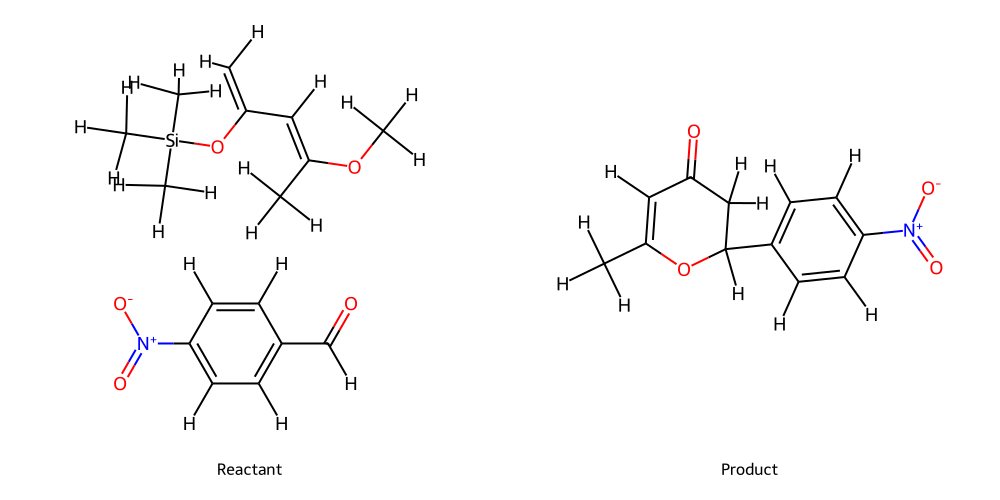

No. 5 Samples C=C(/C=C(\C)OC)O[Si](C)(C)C O=Cc1ccc([N+](=O)[O-])cc1 CC1=CC(=O)CC(c2ccc([N+](=O)[O-])cc2)O1


In [119]:
pred_smi=[]

ps = Chem.SmilesParserParams()
ps.removeHs = False

match_count=0
unmatch_count=0
err_count=0

bh_reaction_smarts = [
                        "([C:1]1=[C:2]([H])-[C:3]-[C:4]([H])=[C:5]1.[C:6]=[C:7]-[C:8])>>[C:1]1=[C:5][C:4]2[C:7]([C:8])[C:6][C:2]1[C:3]2"
                    ]

rxn_match_count=[0 for i in range(len(bh_reaction_smarts))]

irxn=4
train_df=train_df_dict[irxn]
skip={1,3,4}
# for i in range(len(train_df)):
for i in range(100):
    if i in skip: continue
    reactant1_smiles=train_df.iloc[i].Reactant2
    reactant2_smiles=train_df.iloc[i].Reactant1
    product_smiles=train_df.iloc[i].Product
    
    reactant1 = Chem.MolFromSmiles(reactant1_smiles,ps)
    reactant2 = Chem.MolFromSmiles(reactant2_smiles,ps)
    product = Chem.MolFromSmiles(product_smiles,ps)
    reactant1=Chem.AddHs(reactant1)
    reactant2=Chem.AddHs(reactant2)
    product=Chem.AddHs(product)
    
    rmol = Chem.CombineMols(reactant1,reactant2)    
    
    reactions = [AllChem.ReactionFromSmarts(bh_reaction_smarts[i]) for i in range(len(bh_reaction_smarts))]

    # pattern1_smiles="F[B-](F)(F)F"
    # sub_mol=Chem.MolFromSmiles(pattern1_smiles)

    # if rmol.GetSubstructMatches(sub_mol):
    #     # count+=1
    #     continue
        
    revert=False    
    match=False
    for j,reaction in enumerate(reactions):
        try:
            Chem.SanitizeMol(rmol)            
            if len(make_rxns(reaction, [rmol]))==0:
                rmol2 = Chem.CombineMols(reactant2,reactant1)
                Chem.SanitizeMol(rmol2)                
                if len(make_rxns(reaction, [rmol2]))==0:
                    continue
                else:
                    revert=True
                    match=True
            else:
                match=True
            if match: rxn_match_count[j]+=1
            if not revert:
                check=rmol
            else:
                check=rmol2
            for r in make_rxns(reaction, [check]):
                smi = AllChem.ReactionToSmiles(r)
                pred_smi.append(smi)
        except:
            err_count+=1
            img=visualize_reaction(rmol, product)
            im = Image.open(BytesIO(img.data))
            display(im)
            print(f"ERROR No. {i} Samples",reactant1_smiles,reactant2_smiles,product_smiles)
            break
    if match:
        match_count+=1
    else:
        unmatch_count+=1

    if not match:
        img=visualize_reaction(rmol, product)
        im = Image.open(BytesIO(img.data))
        display(im)
        print(f"No. {i} Samples",reactant1_smiles,reactant2_smiles,product_smiles)
        break
        
    # try:
    #     print("clean_smi",clean_smi(smi))
    # except:
    #     err_count+=1
    #     print("Error",smi)

In [120]:
print(err_count,match_count,unmatch_count)
print(rxn_match_count)

0 2 1
[2]


In [121]:
# prod="[C@@H]1[C@@H](C(=O)O[C@@H]2C[C@H](C)CC[C@H]2C(C)C)[C@H]2C=C[C@@H]1C2"
# prod="[C@@H]1[C@@H][C@H]2C=C[C@@H]1C2"
# prod="CC1CCC(C(C)C)C(OC(=O)C2C3C=CC(C3)C2C(=O)OC2CC(C)CCC2C(C)C)C1"

# # prod="C(=O)O[C@@H]2C[C@H](C)CC[C@H]2C(C)C"
# prod_mol=Chem.MolFromSmiles(prod)
# # prod_mol=Chem.AddHs(prod_mol)
# # Chem.SanitizeMol(prod_mol)
# prod_mol=Chem.AddHs(prod_mol)
# prod_mol

In [122]:
bh_reaction_smarts = [
                        "([C:1]1=[C:2]([H])-[C:3]-[C:4]([H])=[C:5]1.[C:6]=[C:7]-[C:8])>>[C:1]1=[C:5][C:4]2[C:7]([C:8])[C:6][C:2]1[C:3]2"
                    ]

patterns=bh_reaction_smarts[0].split(">>")
pattern1=patterns[0][1:-1].split('.')[0]
pattern2=patterns[0][1:-1].split('.')[1]
patten_mol1= Chem.MolFromSmarts(pattern1)
patten_mol2= Chem.MolFromSmarts(pattern2)

print(pattern1,rmol.GetSubstructMatches(patten_mol1))
print(pattern2,rmol.GetSubstructMatches(patten_mol2))

rmol = Chem.CombineMols(reactant1,reactant2)
Chem.SanitizeMol(rmol)

reactions = [AllChem.ReactionFromSmarts(bh_reaction_smarts[i]) for i in range(len(bh_reaction_smarts))]
for reaction in reactions:
    for r in make_rxns(reaction, [rmol]):
        smi = AllChem.ReactionToSmiles(r)
        print("pred product",clean_smi(smi))
print(product_smiles)

[C:1]1=[C:2]([H])-[C:3]-[C:4]([H])=[C:5]1 ()
[C:6]=[C:7]-[C:8] ((0, 1, 2), (2, 3, 4), (3, 2, 1))
CC1=CC(=O)CC(c2ccc([N+](=O)[O-])cc2)O1


## RXN5

In [123]:
pred_smi=[]

ps = Chem.SmilesParserParams()
ps.removeHs = False

match_count=0
unmatch_count=0
err_count=0
                           

bh_reaction_smarts = [
                        "([C,c:1][C,c:2]#[C,c:3].[C,c:4][Br,I,F,Cl:5])>>[C,c:4][C,c:3]#[C,c:2][C,c:1]",
                        "([C,c:1][N:2]([H:3])[H:4].[C,c:5][Br,I,F,Cl:6])>>[C,c:1][N:2]([H:3])[C,c:5]",
                        "([C,c:1][N,n:2][H:3].[C,c:4][Br,I,F,Cl:5])>>[C,c:1][N:2][C,c:4]",
                     ]

bh_reaction_smarts = [
                     "([c,C:1][I,Br,F,Cl].[N,n:2][H:4])>>[C:1][N:2]",
                    "([c,C:1][Br,Cl,I,F].[c,C:3]#[c,C:2][H])>>[C:1][C:2]#[C:3]"
                     ]

rxn_match_count=[0 for i in range(len(bh_reaction_smarts))]

irxn=5
train_df=train_df_dict[irxn]
skip={11}
# skip=set()
for i in range(len(train_df)):
# for i in range(100):
    if i in skip: continue
    reactant1_smiles=train_df.iloc[i].Reactant2
    reactant2_smiles=train_df.iloc[i].Reactant1
    product_smiles=train_df.iloc[i].Product
    
    reactant1 = Chem.MolFromSmiles(reactant1_smiles,ps)
    reactant2 = Chem.MolFromSmiles(reactant2_smiles,ps)
    product = Chem.MolFromSmiles(product_smiles,ps)
    reactant1=Chem.AddHs(reactant1)
    reactant2=Chem.AddHs(reactant2)
    product=Chem.AddHs(product)
    
    rmol = Chem.CombineMols(reactant1,reactant2)    
    
    reactions = [AllChem.ReactionFromSmarts(bh_reaction_smarts[i]) for i in range(len(bh_reaction_smarts))]

    # pattern1_smiles="F[B-](F)(F)F"
    # sub_mol=Chem.MolFromSmiles(pattern1_smiles)

    # if rmol.GetSubstructMatches(sub_mol):
    #     # count+=1
    #     continue
        
    revert=False    
    match=False
    for j,reaction in enumerate(reactions):
        try:
            Chem.SanitizeMol(rmol)            
            if len(make_rxns(reaction, [rmol]))==0:
                rmol2 = Chem.CombineMols(reactant2,reactant1)
                Chem.SanitizeMol(rmol2)                
                if len(make_rxns(reaction, [rmol2]))==0:
                    continue
                else:
                    revert=True
                    match=True
            else:
                match=True
            if match: rxn_match_count[j]+=1
            if not revert:
                check=rmol
            else:
                check=rmol2
            for r in make_rxns(reaction, [check]):
                smi = AllChem.ReactionToSmiles(r)
                pred_smi.append(smi)
        except:
            err_count+=1
            img=visualize_reaction(rmol, product)
            im = Image.open(BytesIO(img.data))
            display(im)
            print(f"ERROR No. {i} Samples",reactant1_smiles,reactant2_smiles,product_smiles)
            break
    if match:
        match_count+=1
    else:
        unmatch_count+=1

    # if not match:
    #     img=visualize_reaction(rmol, product)
    #     im = Image.open(BytesIO(img.data))
    #     display(im)
    #     print(f"No. {i} Samples",reactant1_smiles,reactant2_smiles,product_smiles)
    #     break
        
    # try:
    #     print("clean_smi",clean_smi(smi))
    # except:
    #     err_count+=1
    #     print("Error",smi)

In [124]:
rxn_match_count

[6801, 13]

In [125]:
match_count,unmatch_count,err_count

(6801, 117, 0)

#### 测试

In [126]:
patterns=bh_reaction_smarts[0].split(">>")
pattern1=patterns[0][1:-1].split('.')[0]
pattern2=patterns[0][1:-1].split('.')[1]
patten_mol1= Chem.MolFromSmarts(pattern1)
patten_mol2= Chem.MolFromSmarts(pattern2)

print(pattern1,rmol.GetSubstructMatches(patten_mol1))
print(pattern2,rmol.GetSubstructMatches(patten_mol2))

[c,C:1][I,Br,F,Cl] ((4, 5), (15, 14), (17, 18), (19, 20), (21, 22))
[N,n:2][H:4] ((0, 8), (0, 9))


## RXN6

In [127]:
special_dict={"[K+]"}
def filter(smiles):
    if "." not in smiles:
        return smiles
    clean_smile=[]
    for smi in set(smiles.split('.')):
        if smi in special_dict:
            continue
        # if ('+]' in smi or '-]' in smi) and 'F' in smi:
        #     continue
        clean_smile.append(smi)
    return '.'.join(clean_smile)    

In [128]:
reactant1_smiles

'Nc1ccc(F)cc1'

In [129]:
reactant2_smiles

'Clc1cc(I)c(I)c(I)c1'

In [130]:
pred_smi=[]

ps = Chem.SmilesParserParams()
ps.removeHs = False

match_count=0
unmatch_count=0
err_count=0
                           


bh_reaction_smarts = [
                     "([c,C:1][I,Br,F,Cl].[N,n:2][H:4])>>[C:1][N:2]",
                    "([c,C:1][Br,Cl,I,F].[c,C:3]#[c,C:2][H])>>[C:1][C:2]#[C:3]",
                    "([c,C:1][Br,Cl,I,F].[c,C:3]#[c,C:2][C,c])>>[C:1][C:2]#[C:3]"
    
                     ]

rxn_match_count=[0 for i in range(len(bh_reaction_smarts))]

irxn=6
train_df=train_df_dict[irxn]
# skip={11}
skip=set()
for i in range(len(train_df)):
# for i in range(100):
    if i in skip: continue
    reactant1_smiles=train_df.iloc[i].Reactant2
    reactant2_smiles=train_df.iloc[i].Reactant1
    product_smiles=train_df.iloc[i].Product

    clean_reactant1_smiles=filter(reactant1_smiles)
    clean_reactant2_smiles=filter(reactant2_smiles)    
    
    reactant1 = Chem.MolFromSmiles(clean_reactant1_smiles,ps)
    reactant2 = Chem.MolFromSmiles(clean_reactant2_smiles,ps)
    product = Chem.MolFromSmiles(product_smiles,ps)
    reactant1=Chem.AddHs(reactant1)
    reactant2=Chem.AddHs(reactant2)
    product=Chem.AddHs(product)
    
    rmol = Chem.CombineMols(reactant1,reactant2)    
    
    reactions = [AllChem.ReactionFromSmarts(bh_reaction_smarts[i]) for i in range(len(bh_reaction_smarts))]

    # pattern1_smiles="F[B-](F)(F)F"
    # sub_mol=Chem.MolFromSmiles(pattern1_smiles)

    # if rmol.GetSubstructMatches(sub_mol):
    #     # count+=1
    #     continue
        
    revert=False    
    match=False
    for j,reaction in enumerate(reactions):
        try:
            Chem.SanitizeMol(rmol)            
            if len(make_rxns(reaction, [rmol]))==0:
                rmol2 = Chem.CombineMols(reactant2,reactant1)
                Chem.SanitizeMol(rmol2)                
                if len(make_rxns(reaction, [rmol2]))==0:
                    continue
                else:
                    revert=True
                    match=True
            else:
                match=True
            if match: rxn_match_count[j]+=1
            if not revert:
                check=rmol
            else:
                check=rmol2
            for r in make_rxns(reaction, [check]):
                smi = AllChem.ReactionToSmiles(r)
                pred_smi.append(smi)
        except:
            err_count+=1
            img=visualize_reaction(rmol, product)
            im = Image.open(BytesIO(img.data))
            display(im)
            print(f"ERROR No. {i} Samples",reactant1_smiles,reactant2_smiles,product_smiles)
            break
    if match:
        match_count+=1
    else:
        unmatch_count+=1

    # if not match:
    #     img=visualize_reaction(rmol, product)
    #     im = Image.open(BytesIO(img.data))
    #     display(im)
    #     print(f"No. {i} Samples",reactant1_smiles,reactant2_smiles,product_smiles)
    #     break
        
    # try:
    #     print("clean_smi",clean_smi(smi))
    # except:
    #     err_count+=1
    #     print("Error",smi)

In [131]:
match_count,unmatch_count,err_count

(10465, 0, 0)

In [132]:
bh_reaction_smarts = [
                     "([c,C:1][I,Br,F,Cl].[N,n:2][H:4])>>[C:1][N:2]",
                    "([c,C:1][Br,Cl,I,F].[c,C:2]#[c,C:3][H,C])>>[C:1][C:3]#[C:2]"
                     ]

patterns=bh_reaction_smarts[1].split(">>")
pattern1=patterns[0][1:-1].split('.')[0]
pattern2=patterns[0][1:-1].split('.')[1]
patten_mol1= Chem.MolFromSmarts(pattern1)
patten_mol2= Chem.MolFromSmarts(pattern2)

print(pattern1,rmol.GetSubstructMatches(patten_mol1))
print(pattern2,rmol.GetSubstructMatches(patten_mol2))

rmol = Chem.CombineMols(reactant1,reactant2)
Chem.SanitizeMol(rmol)

reactions = [AllChem.ReactionFromSmarts(bh_reaction_smarts[i]) for i in range(len(bh_reaction_smarts))]
for reaction in reactions:
    for r in make_rxns(reaction, [rmol]):
        smi = AllChem.ReactionToSmiles(r)
        print("pred product",clean_smi(smi))
print(product_smiles)

[c,C:1][Br,Cl,I,F] ((22, 23), (25, 26))
[c,C:2]#[c,C:3][H,C] ()
COC(=O)c1cc(Br)cc(C#C[Si](C)(C)C)c1


## RXN7

In [133]:
pred_smi=[]

ps = Chem.SmilesParserParams()
ps.removeHs = False

match_count=0
unmatch_count=0
err_count=0
                           

# bh_reaction_smarts = [
#                     "([C:1]([H:2])=[C:3][H:4].[N,n:5][C,c:6]@[C,c:8][H:9])>>[C:1]([H:2])([H:4])-[C:3]([H:9])[c:8]@[c:6][n:5]",
#                     "([C:1]([H:2])=[C:3][H:4].[C:5]([H:6])([H:7])[C:8]=[O:9])>>[C:5]([H:6])([C:8]=[O:9])[C:3]([H:4])[C:1]([H:2])([H:7])",
#                     "([C:1]([H:2])=[C:3][H:4].[N:5][H:6])>>[C:1]([H:2])-[C:3]([H:4])[N:5]",
#                      ]

bh_reaction_smarts = [
                    "([C:1]=[C:3][H:4].[N,n:5][C,c:6]@[C,c:8][H:9])>>[C:1]([H:4])-[C:3]([H:9])[c:8]@[c:6][n:5]",
                    "([C:1]=[C:3][H:4].[C:5]([H:6])([H:7])[C:8]=[O:9])>>[C:5]([H:6])([C:8]=[O:9])[C:3]([H:4])[C:1]([H:7])",
                    "([C:1]=[C:3][H:4].[N:5][H:6])>>[C:1]-[C:3]([H:4])[N:5]",
                    "([C:1]#[C:2].[O:3]([H])[C:4])>>[C:1]=[C:2][O:3][C:4]",
                    "([C:1]=[C:2].[O:3]([H:4])[c:5])>>[C:1]([C:2][H:4])[O:3][c:5]",    
                     ]

rxn_match_count=[0 for i in range(len(bh_reaction_smarts))]

irxn=7
train_df=train_df_dict[irxn]
# skip={23,30,33}
# skip=set()
for i in range(len(train_df)):
# for i in range(100):
    if i in skip: continue
    reactant1_smiles=train_df.iloc[i].Reactant2
    reactant2_smiles=train_df.iloc[i].Reactant1
    product_smiles=train_df.iloc[i].Product
    
    reactant1 = Chem.MolFromSmiles(reactant1_smiles,ps)
    reactant2 = Chem.MolFromSmiles(reactant2_smiles,ps)
    product = Chem.MolFromSmiles(product_smiles,ps)
    reactant1=Chem.AddHs(reactant1)
    reactant2=Chem.AddHs(reactant2)
    product=Chem.AddHs(product)
    
    rmol = Chem.CombineMols(reactant1,reactant2)    
    
    reactions = [AllChem.ReactionFromSmarts(bh_reaction_smarts[i]) for i in range(len(bh_reaction_smarts))]

    # pattern1_smiles="F[B-](F)(F)F"
    # sub_mol=Chem.MolFromSmiles(pattern1_smiles)

    # if rmol.GetSubstructMatches(sub_mol):
    #     # count+=1
    #     continue
        
    revert=False    
    match=False
    for j,reaction in enumerate(reactions):
        try:
            Chem.SanitizeMol(rmol)            
            if len(make_rxns(reaction, [rmol]))==0:
                rmol2 = Chem.CombineMols(reactant2,reactant1)
                Chem.SanitizeMol(rmol2)                
                if len(make_rxns(reaction, [rmol2]))==0:
                    continue
                else:
                    revert=True
                    match=True
            else:
                match=True
            if match: rxn_match_count[j]+=1
            if not revert:
                check=rmol
            else:
                check=rmol2
            for r in make_rxns(reaction, [check]):
                smi = AllChem.ReactionToSmiles(r)
                pred_smi.append(smi)
        except:
            err_count+=1
            img=visualize_reaction(rmol, product)
            im = Image.open(BytesIO(img.data))
            display(im)
            print(f"ERROR No. {i} Samples",reactant1_smiles,reactant2_smiles,product_smiles)
            break
    if match:
        match_count+=1
    else:
        unmatch_count+=1

    # if not match:
    #     img=visualize_reaction(rmol, product)
    #     im = Image.open(BytesIO(img.data))
    #     display(im)
    #     print(f"No. {i} Samples",reactant1_smiles,reactant2_smiles,product_smiles)
    #     break
        
    # try:
    #     print("clean_smi",clean_smi(smi))
    # except:
    #     err_count+=1
    #     print("Error",smi)

In [134]:
match_count,unmatch_count,err_count

(4921, 1899, 0)

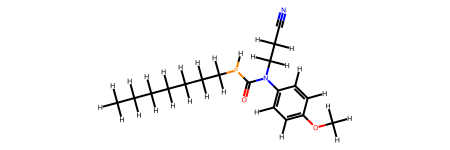

In [135]:
patten_mol2= Chem.MolFromSmarts("[O:3]([H])[c:4]")
# patten_mol2
# # Chem.SanitizeMol(rmol)
rmol.GetSubstructMatches(patten_mol2)

mol=Chem.MolFromSmiles(clean_smi(smi))
mol=Chem.AddHs(mol)
mol

In [136]:
bh_reaction_smarts = [
                    "([C:1]([H:2])=[C:3][H:4].[N,n:5][C,c:6]@[C,c:8][H:9])>>[C:1]([H:2])([H:4])-[C:3]([H:9])[c:8]@[c:6][n:5]",
                    "([C:1]([H:2])=[C:3][H:4].[C:5]([H:6])([H:7])[C:8]=[O:9])>>[C:5]([H:6])([C:8]=[O:9])[C:3]([H:4])[C:1]([H:2])([H:7])",
                    "([C:1]([H:2])=[C:3][H:4].[N:5][H:6])>>[C:1]([H:2])-[C:3]([H:4])[N:5]",
                    "([C:1]#[C:2].[O:3]([H])[C:4])>>[C:1]=[C:2][O:3][C:4]",  
                    "([C:1]=[C:2].[O:3]([H:4])[c:5])>>[C:1]([C:2][H:4])[O:3][c:5]",    
                    ]

patterns=bh_reaction_smarts[4].split(">>")
pattern1=patterns[0][1:-1].split('.')[0]
pattern2=patterns[0][1:-1].split('.')[1]
patten_mol1= Chem.MolFromSmarts(pattern1)
patten_mol2= Chem.MolFromSmarts(pattern2)

print(pattern1,rmol.GetSubstructMatches(patten_mol1))
print(pattern2,rmol.GetSubstructMatches(patten_mol2))

rmol = Chem.CombineMols(reactant1,reactant2)
Chem.SanitizeMol(rmol)

reactions = [AllChem.ReactionFromSmarts(bh_reaction_smarts[i]) for i in range(len(bh_reaction_smarts))]
for reaction in reactions:
    for r in make_rxns(reaction, [rmol]):
        smi = AllChem.ReactionToSmiles(r)
        print("pred product",clean_smi(smi))
print(product_smiles)

[C:1]=[C:2] ((0, 1),)
[O:3]([H:4])[c:5] ()


## RXN8

In [ ]:
pred_smi=[]

ps = Chem.SmilesParserParams()
ps.removeHs = False

match_count=0
unmatch_count=0
err_count=0
                           

# bh_reaction_smarts = [
#                     "([C:1]([H:2])=[C:3][H:4].[N,n:5][C,c:6]@[C,c:8][H:9])>>[C:1]([H:2])([H:4])-[C:3]([H:9])[c:8]@[c:6][n:5]",
#                     "([C:1]([H:2])=[C:3][H:4].[C:5]([H:6])([H:7])[C:8]=[O:9])>>[C:5]([H:6])([C:8]=[O:9])[C:3]([H:4])[C:1]([H:2])([H:7])",
#                     "([C:1]([H:2])=[C:3][H:4].[N:5][H:6])>>[C:1]([H:2])-[C:3]([H:4])[N:5]",
#                      ]

bh_reaction_smarts = [
                    "([CX3:1](=[OX1:2])[Cl:3].[N:4][H])>>[CX3:1](=[OX1:2])[N:4]",
                    "([CX3:1](=[OX1:2])[O].[N:4][H])>>[CX3:1](=[OX1:2])[N:4]",
                     ]

rxn_match_count=[0 for i in range(len(bh_reaction_smarts))]

irxn=8
train_df=train_df_dict[irxn]
skip={9,12}
skip=set()
# for i in range(len(train_df)):
for i in range(100):
    if i in skip: continue
    reactant1_smiles=train_df.iloc[i].Reactant2
    reactant2_smiles=train_df.iloc[i].Reactant1
    product_smiles=train_df.iloc[i].Product
    
    reactant1 = Chem.MolFromSmiles(reactant1_smiles,ps)
    reactant2 = Chem.MolFromSmiles(reactant2_smiles,ps)
    product = Chem.MolFromSmiles(product_smiles,ps)
    reactant1=Chem.AddHs(reactant1)
    reactant2=Chem.AddHs(reactant2)
    product=Chem.AddHs(product)
    
    rmol = Chem.CombineMols(reactant1,reactant2)    
    
    reactions = [AllChem.ReactionFromSmarts(bh_reaction_smarts[i]) for i in range(len(bh_reaction_smarts))]

    # pattern1_smiles="F[B-](F)(F)F"
    # sub_mol=Chem.MolFromSmiles(pattern1_smiles)

    # if rmol.GetSubstructMatches(sub_mol):
    #     # count+=1
    #     continue
        
    revert=False    
    match=False
    for j,reaction in enumerate(reactions):
        try:
            Chem.SanitizeMol(rmol)            
            if len(make_rxns(reaction, [rmol]))==0:
                rmol2 = Chem.CombineMols(reactant2,reactant1)
                Chem.SanitizeMol(rmol2)                
                if len(make_rxns(reaction, [rmol2]))==0:
                    continue
                else:
                    revert=True
                    match=True
            else:
                match=True
            if match: rxn_match_count[j]+=1
            if not revert:
                check=rmol
            else:
                check=rmol2
            for r in make_rxns(reaction, [check]):
                smi = AllChem.ReactionToSmiles(r)
                pred_smi.append(smi)
        except:
            err_count+=1
            img=visualize_reaction(rmol, product)
            im = Image.open(BytesIO(img.data))
            display(im)
            print(f"ERROR No. {i} Samples",reactant1_smiles,reactant2_smiles,product_smiles)
            break
    if match:
        match_count+=1
    else:
        unmatch_count+=1

    if not match:
        img=visualize_reaction(rmol, product)
        im = Image.open(BytesIO(img.data))
        display(im)
        print(f"No. {i} Samples",reactant1_smiles,reactant2_smiles,product_smiles)
        break
        
    # try:
    #     print("clean_smi",clean_smi(smi))
    # except:
    #     err_count+=1
    #     print("Error",smi)

In [ ]:
match_count,unmatch_count,err_count

(100, 0, 0)

In [ ]:
bh_reaction_smarts = [
                    "([CX3:1](=[OX1:2])[Cl:3].[N:4][H])>>[CX3:1](=[OX1:2])[N:4]",
                    "([CX3:1](=[OX1:2])[O].[N:4][H])>>[CX3:1](=[OX1:2])[N:4]",
                    # "([CX3:1](=[OX1:2])[O].[N:4][H])>>[CX3:1](=[OX1:2])[N:4]",
    
    
                     ]

patterns=bh_reaction_smarts[1].split(">>")
pattern1=patterns[0][1:-1].split('.')[0]
pattern2=patterns[0][1:-1].split('.')[1]
patten_mol1= Chem.MolFromSmarts(pattern1)
patten_mol2= Chem.MolFromSmarts(pattern2)

print(pattern1,rmol.GetSubstructMatches(patten_mol1))
print(pattern2,rmol.GetSubstructMatches(patten_mol2))

rmol = Chem.CombineMols(reactant1,reactant2)
Chem.SanitizeMol(rmol)

reactions = [AllChem.ReactionFromSmarts(bh_reaction_smarts[i]) for i in range(len(bh_reaction_smarts))]
for reaction in reactions:
    for r in make_rxns(reaction, [rmol]):
        smi = AllChem.ReactionToSmiles(r)
        print("pred product",clean_smi(smi))
print(product_smiles)

[CX3:1](=[OX1:2])[O] ((13, 14, 12), (18, 19, 20), (35, 36, 37))
[N:4][H] ((1, 6), (34, 80))
pred product CC1CCC([C@H](NC(=O)OCc2ccccc2)c2nc3c(F)c(C4CN(C(=O)OC(C)(C)C)CC4C(=O)N(C)C)ccc3[nH]2)CC1
pred product CC1CCC([C@H]2c3nc4c(F)c(ccc4[nH]3)C3CN(C(=O)OC(C)(C)C)CC3C(=O)N2C(=O)OCc2ccccc2)CC1
pred product CCOC(=O)C1CN(C(=O)N(C)C)CC1c1ccc2[nH]c([C@@H](NC(=O)OCc3ccccc3)C3CCC(C)CC3)nc2c1F
pred product CCOC(=O)C1CN2CC1c1ccc3[nH]c(nc3c1F)[C@H](C1CCC(C)CC1)N(C(=O)OCc1ccccc1)C2=O
pred product CCOC(=O)C1CN(C(=O)OC(C)(C)C)CC1c1ccc2[nH]c([C@@H](NC(=O)N(C)C)C3CCC(C)CC3)nc2c1F
pred product CCOC(=O)C1CN(C(=O)OC(C)(C)C)CC1c1ccc2[nH]c([C@@H](NC=O)C3CCC(C)CC3)nc2c1F
pred product CC1CCC([C@H](NC(=O)OCc2ccccc2)c2nc3c(F)c(C4CN(C(=O)OC(C)(C)C)CC4C(=O)N(C)C)ccc3[nH]2)CC1
pred product CC1CCC([C@H]2c3nc4c(F)c(ccc4[nH]3)C3CN(C(=O)OC(C)(C)C)CC3C(=O)N2C(=O)OCc2ccccc2)CC1
pred product CCOC(=O)C1CN(C(=O)N(C)C)CC1c1ccc2[nH]c([C@@H](NC(=O)OCc3ccccc3)C3CCC(C)CC3)nc2c1F
pred product CCOC(=O)C1CN2CC1c1ccc3[nH]c(nc3c1F)[C

# Additives-1770

In [ ]:
columns=['Reactant1','Reactant2','Product','Additive','Solvent']
irxn=8
icol=3
col=columns[icol]
search_word="P"
print(f"For Col:{col}")
add_set=set()
for j in range(1,9):
    print(f"For Reaction:{j}")
    word_count=0
    pattern_count=0
    train_df=train_df_dict[j]
    for i in range(len(train_df)):
    # for i in range(100):    
        smiles=train_df.iloc[i][col]
        add_set.update(set(smiles.split("."))) 

For Col:Additive
For Reaction:1
For Reaction:2
For Reaction:3
For Reaction:4
For Reaction:5
For Reaction:6
For Reaction:7
For Reaction:8


In [ ]:
atom_prop_to_smarts = {
    "IsHydrophobe":  #s疏水基团 
        {"hydrophobe": Chem.MolFromSmarts("[#6+0!$(*~[#7,#8,F]),SH0+0v2,s+0,Cl+0,Br+0,I+0,F+0$(F-C-[F,Cl,Br,I])]")},
    "IsHDonor":
        {"donor": Chem.MolFromSmarts('['
                                     '$([N&!H0&v3,N&!H0&+1&v4,n&H1&+0]),'
                                     '$([$(n[n;H1]),$(nc[n;H1])]),'
                                     '$([Nv3;$([N;H0]=C-[N;!H0])]),'
                                     '$([O,S;H1;+0;!$(O-[C;v4]=[O;H0])])'
                                     ']')},
    "IsWeakHDonor":
        {"donor": Chem.MolFromSmarts("[#6!H0]")},
    "IsXDonor":
        {"donor": Chem.MolFromSmarts("[Cl,Br,I;X1;$([Cl,Br,I]-[#6])]")},
    "IsHAcceptor":
        {"acceptor": Chem.MolFromSmarts('['
                                        '$([O;H1;v2]),'
                                        '$([O;H0;v2;!$(O=N-*)]),'
                                        '$([O;-;!$(*-N=O)]),'
                                        '$([o;+0]),'
                                        '$([n;+0;!X3]),'
                                        '$([n;+0;X3;H1;$([n;H1][n;H0]),$([n;H1]c[n;H0])]),'
                                        '$([N;H0;$(N#[C&v4])]),'
                                        '$([N&v3;H0;$(Nc)]),'
                                        '$([N&v3;H0;$(N=C);!$(N=C-[N;!H0])]),'
                                        '$([F;$(F-[#6]);!$(FC[F,Cl,Br,I])])'
                                        ']')},
    "IsPositive":
        {"rdkit basic group": Chem.MolFromSmarts("["
                                                 "$([Nv3;$([N;!H0]-C=N),$([N;H0]=C-[N;!H0]),$([N;H1]=C-N)]),"
                                                 "$([N;H2&+0][C;!$(C=*)]),"
                                                 "$([N;H1&+0]([C;!$(C=*)])[C;!$(C=*)]);"
                                                 "!$(N[a])"
                                                 "]"),
         "rdkit posn": Chem.MolFromSmarts("[#7;+;!$([N+]-[O-])]"),
         "cations": Chem.MolFromSmarts("[$([*+1,*+2,*+3]);!$([N+]-[O-])]"),
         "metals": Chem.MolFromSmarts("[Li,Be,Na,Mg,Al,K,Ca,Sc,Ti,V,Cr,Mn,Fe,Co,Ni,Cu,Zn,Ga,Rb,Sr,Y,Zr,Nb,Mo,Tc,Ru,Rh,"
                                      "Pd,Ag,Cd,In,Sn,Cs,Ba,La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf,Ta,W,Re,Os,"
                                      "Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,Fr,Ra,Ac,Th,Pa,U,Np,Pu,Am,Cm,Bk,Cf]")},
    "IsNegative":
        {"O acidic group": Chem.MolFromSmarts("["
                                              "$([OH,O-]-[C,S,N,P,Cl,Br,I]=O),"
                                              "$(O=[C,S,N,P,Cl,Br,I]-[OH,O-])"
                                              "]"),
         "anions": Chem.MolFromSmarts("[*-1,*-2]")},
}

CC(C)(C)[O-]碱性 叔丁醇碱

- Cations: 最终效果： 这个 SMARTS 匹配 阳离子（带 +1、+2 或 +3 电荷的原子），但 排除了 氮氧离子对（如 NO₃⁻）的情况。
- rdkit basic group 总结：这个 SMARTS 表达式匹配的主要是 含氮的碱性基团，主要是以下几种类型：亚胺类基团（C=N 结构）或其他氮-碳-氮结构。胺类基团，氮原子与不带双键的碳原子相连。
排除了芳香氮原子。这些结构在化学中通常显示碱性，因此该表达式用于识别那些可能与质子结合的 碱性官能团，例如胺和亚胺。
- rdkit posn 带正电荷的氮离子 通常是质子化的产物，因此与 酸性 环境相关。
- O acidic group 代表的具体化学基团：羧酸（R-COOH）：例如乙酸。磺酸（R-SO₃H）：例如对甲苯磺酸。酯类（R-COOR'）：例如乙酸乙酯。磷酸酯：例如磷酸二乙酯。 这些基团中氧原子通常具有酸性，

In [ ]:
atom_prop_to_smarts

{'IsHydrophobe': {'hydrophobe': <rdkit.Chem.rdchem.Mol at 0x7f6333e644a0>},
 'IsHDonor': {'donor': <rdkit.Chem.rdchem.Mol at 0x7f6333e64510>},
 'IsWeakHDonor': {'donor': <rdkit.Chem.rdchem.Mol at 0x7f6333e64580>},
 'IsXDonor': {'donor': <rdkit.Chem.rdchem.Mol at 0x7f6333e645f0>},
 'IsHAcceptor': {'acceptor': <rdkit.Chem.rdchem.Mol at 0x7f6333e64660>},
 'IsPositive': {'rdkit basic group': <rdkit.Chem.rdchem.Mol at 0x7f6333e646d0>,
  'rdkit posn': <rdkit.Chem.rdchem.Mol at 0x7f6333e64740>,
  'cations': <rdkit.Chem.rdchem.Mol at 0x7f6333e647b0>,
  'metals': <rdkit.Chem.rdchem.Mol at 0x7f6333e649e0>},
 'IsNegative': {'O acidic group': <rdkit.Chem.rdchem.Mol at 0x7f6333e64dd0>,
  'anions': <rdkit.Chem.rdchem.Mol at 0x7f6333e64e40>}}

In [ ]:
prop_listkey=[]
prop_mol=[]
i=0
for prop, smarts in atom_prop_to_smarts.items():
    for k, v in smarts.items():
        prop_listkey.append(f"{prop}_{k}")
        prop_mol.append(v)
        i+=1

In [ ]:
all_sets=[set() for i in range(len(prop_mol))]

for smi in add_set:
    mol=Chem.MolFromSmiles(smi)
    for i,patmol in enumerate(prop_mol):
        if len(mol.GetSubstructMatches(patmol))>0:
            all_sets[i].add(smi)

for i,setss in enumerate(all_sets):
    print(prop_listkey[i],len(setss))

IsHydrophobe_hydrophobe 1530
IsHDonor_donor 729
IsWeakHDonor_donor 1553
IsXDonor_donor 119
IsHAcceptor_acceptor 1188
IsPositive_rdkit basic group 263
IsPositive_rdkit posn 170
IsPositive_cations 288
IsPositive_metals 190
IsNegative_O acidic group 210
IsNegative_anions 189


### 酸

排除金属与膦配体

In [ ]:
#ACID
pattern = [
        "[O;H1]-[C,S,P]=O",
        "[*;-;!$(*~[*;+])]",
        "[NH](S(=O)=O)C(F)(F)F",
        "n1nnnc1",
]

https://github.com/JacksonBurns/mordred-community/blob/23a3a3967968e9585b821de97ffca6095ff580d7/mordred/AcidBase.py#L18

In [ ]:
remov_pat=[
    "[P]",#300
    "[Li,Be,Na,Mg,Al,K,Ca,Sc,Ti,V,Cr,Mn,Fe,Co,Ni,Cu,Zn,Ga,Rb,Sr,Y,Zr,Nb,Mo,Tc,Ru,Rh,"
                              "Pd,Ag,Cd,In,Sn,Cs,Ba,La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf,Ta,W,Re,Os,"
                              "Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,Fr,Ra,Ac,Th,Pa,U,Np,Pu,Am,Cm,Bk,Cf]", #190
    "[$([OH,O-]-[C,S,N,P,Cl,Br,I]=O),$(O=[C,S,N,P,Cl,Br,I]-[OH,O-])]", #170/1281 羧酸（R-COOH）：例如乙酸。磺酸（R-SO₃H）：例如对甲苯磺酸。酯类（R-COOR'）：例如乙酸乙酯。磷酸酯：例如磷酸二乙酯。 这些基团中氧原子通常具有酸性，
    "[$([Nv3;$([N;!H0]-C=N),$([N;H0]=C-[N;!H0]),$([N;H1]=C-N)]),$([N;H2&+0][C;!$(C=*)]),$([N;H1&+0]([C;!$(C=*)])[C;!$(C=*)]);!$(N[a])]", #氨基，碱性224/1281
    "[#7;+;!$([N+]-[O-])]", #145
    ]
# pattern=[
#     # "[B]",#57/1771
#     "[#7;+;!$([N+]-[O-])]", 
    
#     ]
pattern = [ #Morded
        "[O;H1]-[C,S,P]=O",
        "[*;-;!$(*~[*;+])]",
        "[NH](S(=O)=O)C(F)(F)F",
        "n1nnnc1",
        "[NH2]-[CX4]",
        "[NH](-[CX4])-[CX4]",
        "N(-[CX4])(-[CX4])-[CX4]",
        "[*;+;!$(*~[*;-])]",
        "N=C-N",
        "N-C=N",
]
match_set=set()
remove_mol=[Chem.MolFromSmarts(pat) for pat in remov_pat]
pattern_mol=[Chem.MolFromSmarts(pat) for pat in pattern]

def search_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    match=False
    for patmol in pattern_mol:
        if len(mol.GetSubstructMatches(patmol))>0:
            match=True
    return match
    
def remove_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    remove=False
    for revmol in remove_mol:
        if len(mol.GetSubstructMatches(revmol))>0:
            remove=True
    return remove

In [ ]:
count=0
for smi in add_set:
    # if not remove_pattern(smi): 
    if not remove_pattern(smi) and search_pattern(smi): 
        count+=1
        print(smi)
        match_set.add(smi)
        # break
print(f"{count}/{1281}")

C1CCC(N(C2CCCCC2)C2CCCCC2)CC1
CCCCCCCCc1cc(/C=N/[C@@H](Cc2ccccc2)C(O)(c2ccc(CCN(C)C)cc2)c2ccc(CCN(C)C)cc2)c(O)c(C(F)(F)F)c1
CC[N+]([O-])(CC)CC
c1ccc(N/N=C(\CN2CCCCC2)c2ccccc2)cc1
C=C[C@H]1C[N@@]2CC[C@H]1C[C@@H]2[C@H](Nc1c(NCc2cc(C(F)(F)F)cc(C(F)(F)F)c2)c(=O)c1=O)c1ccnc2ccccc12
CN1CCCN2CCCN=C12
CN1CCN(C)CC1
C=C[C@H]1C[N@@]2CC[C@H]1C[C@@H]2C(Oc1cc2ccccc2c2ccccc12)c1ccnc2ccc(O)cc12
C=C[C@H]1C[N@@]2CC[C@H]1C[C@@H]2[C@H](NC(=S)Nc1cc(C(F)(F)F)cc(C(F)(F)F)c1)c1ccnc2ccc(OC)cc12
CN(C)CCNc1c(NCc2cc(C(F)(F)F)cc(C(F)(F)F)c2)c(=O)c1=O
CN(C)CCCN(C)C
O=C(NNC(=O)C1CCC[N+]1([O-])Cc1ccccc1)c1ccccc1
C=C[C@H]1C[N@@]2CC[C@H]1C[C@H]2CN(c1c(Nc2cc(C(F)(F)F)cc(C(F)(F)F)c2)c(=O)c1=O)c1ccnc2ccc(OC)cc12
C=CC1CN2CCC1CC2[C@@H](Nc1c(Nc2cc(C(F)(F)F)cc(C(F)(F)F)c2)c(=O)c1=O)c1ccnc2ccccc12
CCN(CC)C(C)C
CN(C)Cc1ccncc1
CN(C)C1CCCCC1
CN(C)[C@@H]1CCCC[C@H]1NC(=S)Nc1cc(C(F)(F)F)cc(C(F)(F)F)c1
c1ccc([C+]2c3ccc4ccc5ccccc5c4c3-c3c2ccc2ccc4ccccc4c32)cc1
CC(C)[C@@H](CN(C)C)Nc1c(NCc2ccccc2)c(=S)c1=S
CN(C)C(=[O+]N1C(=O)CCC1=O)N(C)

### 碱

## 金属-190

In [ ]:
metal_smarts=Chem.MolFromSmarts("[Li,Be,Na,Mg,Al,K,Ca,Sc,Ti,V,Cr,Mn,Fe,Co,Ni,Cu,Zn,Ga,Rb,Sr,Y,Zr,Nb,Mo,Tc,Ru,Rh,"
                              "Pd,Ag,Cd,In,Sn,Cs,Ba,La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf,Ta,W,Re,Os,"
                              "Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,Fr,Ra,Ac,Th,Pa,U,Np,Pu,Am,Cm,Bk,Cf]")

In [ ]:
carbon_smarts=Chem.MolFromSmarts("[C,c]")

In [ ]:
metal_organic=set()
metal_inorganic=set()
metal_all=set()
for smi in add_set:
    mol=Chem.MolFromSmiles(smi)
    if len(mol.GetSubstructMatches(metal_smarts))>0: 
        if len(mol.GetSubstructMatches(carbon_smarts))>0:
            metal_organic.add(smi)
        else:
            metal_inorganic.add(smi)     
        metal_all.add(smi)

In [ ]:
len(metal_organic)

101

### 金属无机-89

In [ ]:
metal_inorganic

{'Cl[Au-](Cl)(Cl)Cl',
 'Cl[Au]',
 'Cl[Ni]Cl',
 'Cl[Pd-2](Cl)(Cl)Cl',
 'Cl[Pd]Cl',
 'Cl[Ti](Cl)(Cl)Cl',
 'O=N[Fe-2]',
 'O=P(O)(O)O[Mo](=O)(=O)O',
 'O=P(O)(O)O[W](=O)(=O)O',
 'O=[Cr]([O-])[O-]',
 'O=[Mn](=O)(=O)[O-]',
 'O=[V+2]',
 'O=[V](=O)[O-]',
 '[Ag+2]',
 '[Ag+]',
 '[Ag]',
 '[Al+3]',
 '[Au+3]',
 '[Ba+2]',
 '[Bi+3]',
 '[Bi]',
 '[Ca+2]',
 '[Cd+2]',
 '[Ce+3]',
 '[Ce+4]',
 '[Co+2]',
 '[Cr+2]',
 '[Cr+3]',
 '[Cr+6]',
 '[Cs+]',
 '[Cu+2]',
 '[Cu+]',
 '[Cu]',
 '[Cu]Br',
 '[Er+3]',
 '[Eu+3]',
 '[Fe+2]',
 '[Fe+3]',
 '[Fe]',
 '[Ga+3]',
 '[Hf+4]',
 '[In+3]',
 '[In]',
 '[K+]',
 '[K]',
 '[La+3]',
 '[La]',
 '[Li+]',
 '[Li]',
 '[Mg+2]',
 '[Mg]',
 '[Mn+2]',
 '[Mn+3]',
 '[Mn+4]',
 '[Mo]',
 '[Na+]',
 '[Na]',
 '[Nb+5]',
 '[Ni+2]',
 '[Ni]',
 '[O][V+5]',
 '[Os+8]',
 '[Pb+4]',
 '[Pd+2]',
 '[Pd+3]',
 '[Pd+]',
 '[Pd]',
 '[Pt+2]',
 '[Pt+4]',
 '[Rb+]',
 '[Rh+2]',
 '[Rh+]',
 '[Ru+2]',
 '[Ru+4]',
 '[RuH2]',
 '[Sc+3]',
 '[Sm+2]',
 '[Sm+3]',
 '[Sm]',
 '[Sn+2]',
 '[Sn+4]',
 '[Ti+4]',
 '[Tl+]',
 '[Y+3]',
 '[Yb+3]',
 

多为催化剂
-  'Cl[Au-](Cl)(Cl)Cl',
-  'Cl[Au]',
-  'Cl[Ni]Cl',
-  'Cl[Pd-2](Cl)(Cl)Cl',
-  'Cl[Pd]Cl',
-  'Cl[Ti](Cl)(Cl)Cl',
-  'O=N[Fe-2]',
-  'O=P(O)(O)O[Mo](=O)(=O)O',
-  'O=P(O)(O)O[W](=O)(=O)O',
-  'O=[Cr]([O-])[O-]',
-  'O=[Mn](=O)(=O)[O-]',
-  'O=[V+2]',
-  'O=[V](=O)[O-]',

### 金属有机-101

- 格式试剂  
    - Br[Mg]c1ccccc1   结构：溴化镁与苯环（C₆H₅）形成的有机镁化合物。类型：格氏试剂的一种。
    - CC(C)(C)[Mg]Cl 结构：异丁基镁氯化物。类型：格氏试剂。
    - CH₃MgBr（溴化甲基镁）PhMgCl（氯化苯基镁）
    - 结构：含有金属镁（Mg），通常表示为 RMgX，其中 R 是烷基或芳基，X 是卤素（如 Cl、Br、I）。
    - 用途：格氏试剂常用于有机合成中的 碳-碳键形成反应，通过与醛、酮或酯类化合物反应生成醇类。
- 配合物
    - C1=CCC([Hf+2]C2=CC=CC2)=C1
    - C1=CCC([Ti+2]C2=CC=CC2)=C1 铪配合物。钛配合物。
- Pd配合物
    -   CC(C)(C)[PH]([Pd+2][PH](C(C)(C)C)(C(C)(C)C)C(C)(C)C)(C(C)(C)C)C(C)(C)C 含钯的多膦配合物。
    -   Pd(OAc)₂（乙酸钯）
- 有机锂化合物（Organolithium Compounds）
    - 结构：含有锂（Li），一般为 RLi 形式，其中 R 是烷基或芳基。
    - 例子：n-BuLi（正丁基锂） PhLi（苯基锂）
    - 用途：有机锂化合物是强碱和强亲核试剂，常用于 有机合成 中的去质子化反应和碳-碳键形成反应。
- 有机金属化合物
    - 有机铝化合物 通常为 R₃Al 或 R₂AlX 形式 这些化合物广泛用于 Ziegler-Natta 催化剂 系统中，用于烯烃聚合反应。Al(CH₃)₃（三甲基铝）AlEt₂Cl（二乙基氯化铝）
    - 有机锌化合物 通常为 R₂Zn 或 RZnX 形式。 用途：有机锌化合物常用于 碳-碳键形成反应，如 Negishi 偶联反应和 Simmons-Smith 反应中。
    - 有机锡化合物 含有锡（Sn），通常为 R₄Sn 或 R₃SnX 形式，其中 R 是烷基或芳基，X 是卤素或其他配体。  Stille 偶联反应 Bu₃SnCl（三丁基氯化锡） Me₄Sn（四甲基锡）
    - 有机钯化合物 用途：钯催化剂广泛用于 交叉偶联反应（如 Heck、Suzuki、Stille 等反应）中。Pd(PPh₃)₄（四三苯基膦钯） Pd(OAc)₂（乙酸钯）
    - 有机铂化合物 广泛用于 加氢反应、催化 和 有机合成。  Pt(PPh₃)₂Cl₂（二氯二三苯基膦铂）Pt(C₂H₄)(PPh₃)₂
    - 有机镍化合物 镍催化剂用于 交叉偶联反应 和 烯烃聚合。 Ni(PPh₃)₂Cl₂ Ni(CO)₄
    - 有机金化合物 有机金催化剂在有机合成中具有广泛应用，特别是在 碳-碳和碳-氮键形成 中。Au(PPh₃)Cl（氯化三苯基膦金）AuCl₃（三氯化金）
- 碳基配合物（Carbene Complexes）
    - 结构：金属中心与一个 卡宾基团（=CR₂） 相连，R 通常是氢、烷基或芳基。
    - 例子：Fischer Carbene（费舍尔卡宾，金属与电子给予型配体，如羰基，配合）
    - Schrock Carbene（施洛克卡宾，金属与电子吸收型配体，形成强配合键）
    - 用途：卡宾配合物广泛用于 烯烃聚合反应 和 催化循环 中。


In [ ]:
remov_pat=[
    "[P]",#10/190
    "[C,c][Mg,Li,Zn,Cu,Cd,Ca,Al,Sr,Ba][Cl,Br,I]",#格氏试剂 9/101-91
    "[Pd][Cl,Br,I,F]",   #28/101
    "[C,c]~[Pd]",   #19/101    
    "[O][Pd][O]",   #2/101  
    "[Pd][N]",
    ]
pattern=[       
    # "[O][Pd][O]",   #12/101    
    "[Pd][N]"
    ]
match_set=set()
remove_mol=[Chem.MolFromSmarts(pat) for pat in remov_pat]
pattern_mol=[Chem.MolFromSmarts(pat) for pat in pattern]
def search_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    match=False
    for patmol in pattern_mol:
        if len(mol.GetSubstructMatches(patmol))>0:
            match=True
            break
    return match
def remove_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    remove=False
    for revmol in remove_mol:
        if len(mol.GetSubstructMatches(revmol))>0:
            remove=True
            break
    return remove

In [ ]:
count=0
for smi in metal_organic:
    # if not remove_pattern(smi) and search_pattern(smi): 
    if not remove_pattern(smi):         
        count+=1
        print(smi)
        match_set.add(smi)
        # break
print(f"{count}/{len(metal_organic)}")

CC[Al+2]
C[Al]
Cc1cc(C)c(N2CCN(c3c(C)cc(C)cc3C)C2=[Ru-2]=Cc2ccccc2)c(C)c1
CC[Al](CC)CC
[Li]CCCCCC
C[Al+2]
[Li]C(C)CC
CCCC[Sn+](CCCC)CCCC
C[Re](=O)(=O)=O
CC[Zn]CC
Cc1cc(C)c(-n2ccn(-c3c(C)cc(C)cc3C)c2=[Cu-2]Cl)c(C)c1
C1=CCC([Ti+2]C2=CC=CC2)=C1
C[Zn]C
C1=CCC([Hf+2]C2=CC=CC2)=C1
[Li]c1ccccc1
C[Al+]C
CC(C)c1cccc(C(C)C)c1-n1ccn(-c2c(C(C)C)cccc2C(C)C)c1=[Cu-2]Cl
C[Al](C)C
[Li]CCCC
CC[Al+]CC
O=C(O[Ag])C(F)(F)F
S=[Sn](c1ccccc1)c1ccccc1
[Li]C(C)(C)C
CC(C)C[Al+]CC(C)C
I[Fe]C1=CC=CC1
[Li]C
CCCCO[Sn](=O)O
CC(C)c1cccc(C(C)C)c1-n1ccn(-c2c(C(C)C)cccc2C(C)C)c1=[Au-2]Cl
CCCCO[Ti](OCCCC)(OCCCC)OCCCC
Cc1ccccc1[Zn+]
C[Ni]C
CC(C)C[Al](CC(C)C)CC(C)C
N#C[Fe-3](C#N)(C#N)(C#N)(C#N)C#N
33/101


催化剂
- Cc1cc(C)c(N2CCN(c3c(C)cc(C)cc3C)C2=[Ru-2]=Cc2ccccc2)c(C)c1
- CCCCSn+CCCC
- CC[Zn]CC
- Cc1cc(C)c(-n2ccn(-c3c(C)cc(C)cc3C)c2=[Cu-2]Cl)c(C)c1
- C1=CCC([Ti+2]C2=CC=CC2)=C1
- C1=CCC([Hf+2]C2=CC=CC2)=C1
- C[Al+]C
亲核反应
- [Li]c1ccccc1

## Ligand-300

In [ ]:
pattern=[
    "[P]([C,c])[C,c]",
    "[P][N,n].[N,n][P]",
    "[P]([N])～([N])[P]",    
    "[P][C](=O)",
    "[P](=O)O",
    "[P]([O])([O])([O])",  #6/ P与三个O相连
    "[P][Li,Be,Na,Mg,Al,K,Ca,Sc,Ti,V,Cr,Mn,Fe,Co,Ni,Cu,Zn,Ga,Rb,Sr,Y,Zr,Nb,Mo,Tc,Ru,Rh,"
          "Pd,Ag,Cd,In,Sn,Cs,Ba,La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf,Ta,W,Re,Os,"
          "Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,Fr,Ra,Ac,Th,Pa,U,Np,Pu,Am,Cm,Bk,Cf]",  #膦配体 3
    "[C,c][P]",   
    "[P]"
    ]
pattern_mol=[Chem.MolFromSmarts(pat) for pat in pattern]
def search_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    match=False
    for patmol in pattern_mol:
        if len(mol.GetSubstructMatches(patmol))>0:
            match=True
    return match

In [ ]:
P_Ligand=set()
for smi in add_set:
    if search_pattern(smi):P_Ligand.add(smi)
print(len(P_Ligand))
# print(list(P_Ligand))

312


In [ ]:
P_Ligand

{'BOP',
 'Br[P+](N1CCCC1)(N1CCCC1)N1CCCC1',
 'C(=C(\\c1ccccc1)c1cccc(/C(=C/c2ccccc2)c2ccccc2)c1-c1ccccc1P(C1CCCCC1)C1CCCCC1)\\c1ccccc1',
 'C1CCC(P(C2CCCCC2)C2CCCCC2)CC1',
 'C1CCC(P(C2CCCCC2)N2CCCCC2)CC1',
 'C1CCC(P(CCP(C2CCCCC2)C2CCCCC2)C2CCCCC2)CC1',
 'C1CCN(P(N2CCCCC2)N2CCCCC2)CC1',
 'CC(C)(C)CP(C(C)(C)C)C(C)(C)C',
 'CC(C)(C)CP(CC(C)(C)C)CC(C)(C)C',
 'CC(C)(C)C[PH+](C(C)(C)C)C(C)(C)C',
 'CC(C)(C)N1N(Cl)P(C(C)(C)C)P1Cl',
 'CC(C)(C)N=P(N1CCCC1)(N1CCCC1)N1CCCC1',
 'CC(C)(C)OC(=O)N[C@@H](Cc1ccccc1)CP(c1ccccc1)c1ccccc1',
 'CC(C)(C)OP(=O)(OC(C)(C)C)OC(C)(C)C',
 'CC(C)(C)P(=O)(c1ccccc1-c1ccccc1)C(C)(C)C',
 'CC(C)(C)P(Br)(Br)(C(C)(C)C)C(C)(C)C',
 'CC(C)(C)P(C(C)(C)C)C(C)(C)C',
 'CC(C)(C)P(C(C)(C)C)C12CC3CC(CC(C3)C1)C2',
 'CC(C)(C)P(C1CCCCC1)C1CCCCC1',
 'CC(C)(C)P(CCCCCCP(C(C)(C)C)C(C)(C)C)C(C)(C)C',
 'CC(C)(C)P(Cl)C(C)(C)C',
 'CC(C)(C)P(c1cccc(-c2ccccc2)c1)C(C)(C)C',
 'CC(C)(C)P(c1ccccc1)C(C)(C)C',
 'CC(C)(C)P(c1ccccc1)c1ccccc1',
 'CC(C)(C)P(c1ccccc1-c1ccc2ccc3cccc4ccc1c2c34)C(C)(C)C',
 'CC(

In [ ]:
P_Ligand2-P_Ligand

{'BOP',
 'ClP(Cl)(Cl)(Cl)Cl',
 'ClP(Cl)Cl',
 'F[P-](F)(F)(F)(F)F',
 'O=P(Cl)(Cl)Cl',
 'P',
 'PS'}

In [ ]:
P_Ligand2=set(P_Ligand)

## Reaction Explorer

In [ ]:
special_dict={"[K+]","[Zn+2],[Pd+2]"}
def filter(smiles):
    if "." not in smiles:
        return smiles
    # clean_smile=[]
    # for smi in set(smiles.split('.')):
    #     if smi in special_dict:
    #         continue
    #     # if ('+]' in smi or '-]' in smi) and 'F' in smi:
    #     #     continue
    #     clean_smile.append(smi)
    
    return '.'.join(list(set(smiles.split('.'))))
    # return '.'.join(clean_smile)    

In [ ]:
ion_set={"[K+]","[Zn+2]","[Pd+2]","[Pd]","[H+]","[Na+]"}
P_set={"P([O-])([O-])[O-]"}

def filter(smiles):
    if "." not in smiles:
        return smiles
    # clean_smile=[]
    # for smi in set(smiles.split('.')):
    #     if smi in special_set:
    #         continue
    #     # if ('+]' in smi or '-]' in smi) and 'F' in smi:
    #     #     continue
    #     clean_smile.append(smi)
    smiles_set=set(smiles.split('.'))
    for token in special_set:
        if token in smiles_set:
            smiles_set.remove(token)
    return '.'.join(list(smiles_set))
    # return '.'.join(clean_smile)    

In [ ]:
remov_pat=[
    # "[n1ccccc1]",
    # "[NX3,NX3H2,NX3H1]"
    # "[nH]1cnc[nH]1",    #0
    # "[Pd,Li,Al,Zn,Sn,Pt,Ni,Au]"
    # "[Pd]"
    ]
pattern=[       
    "[P].[Pd,Li,Al,Zn,Sn,Pt,Ni,Au]"
    ]
match_set=set()
remove_mol=[Chem.MolFromSmarts(pat) for pat in remov_pat]
pattern_mol=[Chem.MolFromSmarts(pat) for pat in pattern]
def search_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    match=False
    for patmol in pattern_mol:
        if len(mol.GetSubstructMatches(patmol))>0:
            match=True
            break
    return match
def remove_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    remove=False
    for revmol in remove_mol:
        if len(mol.GetSubstructMatches(revmol))>0:
            remove=True
            break
    return remove

### 整体探索

#### [Pd,Li,Al,Zn,Sn,Pt,Ni,Au]

- For Reaction:1 Searched for Pd count:3153/23538
- For Reaction:2 Searched for Pd count:14455/14455
- For Reaction:3 Searched for Pd count:5423/5423
- For Reaction:4 Searched for Pd count:49/3292
- For Reaction:5 Searched for Pd count:5135/6919
- For Reaction:6 Searched for Pd count:10465/10465
- For Reaction:7 Searched for Pd count:26/6820
- For Reaction:8 Searched for Pd count:7/25940

#### Pd

- For Col:Additive
- For Reaction:1 Searched for Pd count:99/23538
- For Reaction:2 Searched for Pd count:934/14455
- For Reaction:3 Searched for Pd count:295/5423
- For Reaction:4 Searched for Pd count:20/3292
- For Reaction:5 Searched for Pd count:195/6919
- For Reaction:6 Searched for Pd count:105/10465
- For Reaction:7 Searched for Pd count:5/6820
- For Reaction:8 Searched for Pd count:0/25940

#### P-[Pd,Li,Al,Zn,Sn,Pt,Ni,Au]

- For Col:Additive
- For Reaction:1 Searched for Pd count:3048/23538
- For Reaction:2 Searched for Pd count:12952/14455
- For Reaction:3 Searched for Pd count:3020/5423
- For Reaction:4 Searched for Pd count:11/3292
- For Reaction:5 Searched for Pd count:4968/6919
- For Reaction:6 Searched for Pd count:10413/10465
- For Reaction:7 Searched for Pd count:18/6820
- For Reaction:8 Searched for Pd count:9/25940

#### P

For Col:Additive
For Reaction:1
Searched for P count:4811/23538
For Reaction:2
Searched for P count:12952/14455
For Reaction:3
Searched for P count:3020/5423
For Reaction:4
Searched for P count:148/3292
For Reaction:5
Searched for P count:5491/6919
For Reaction:6
Searched for P count:10413/10465
For Reaction:7
Searched for P count:507/6820
For Reaction:8
Searched for P count:4833/25940

### RXN1

In [ ]:
remov_pat=[
    # "[n1ccccc1]",
    # "[NX3,NX3H2,NX3H1]"
    # "[nH]1cnc[nH]1",    #0
    # "[Pd,Li,Al,Zn,Sn,Pt,Ni,Au]"
    # "[Pd]"
    ]
pattern=[       
    "[P].[Pd,Li,Al,Zn,Sn,Pt,Ni,Au]"
    ]
match_set=set()
remove_mol=[Chem.MolFromSmarts(pat) for pat in remov_pat]
pattern_mol=[Chem.MolFromSmarts(pat) for pat in pattern]
def search_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    match=False
    for patmol in pattern_mol:
        if len(mol.GetSubstructMatches(patmol))>0:
            match=True
            break
    return match
def remove_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    remove=False
    for revmol in remove_mol:
        if len(mol.GetSubstructMatches(revmol))>0:
            remove=True
            break
    return remove

In [ ]:
columns=['Reactant1','Reactant2','Product','Additive','Solvent']
irxn=8
icol=3
col=columns[icol]
search="Pd"
print(f"For Col:{col}")
# for j in range(1,9):
for j in range(1,2):    
    word_count=0
    pattern_count=0
    train_df=train_df_dict[j]
    for i in range(len(train_df)):
    # for i in range(100):    
        smiles=train_df.iloc[i][col]
        if search_pattern(smiles): 
            pattern_count+=1
            # print("    ",smiles)            
        else:
            pass
            print("    ",smiles)                        
    print(f"For Reaction:{j} Searched for {search} count:{pattern_count}/{len(train_df)}")      

For Col:Additive
     C1COCCOCCOCCOCCOCCO1.O=C([O-])[O-].[Cu+].[I-].[K+].[K+]
     CCN(C(C)C)C(C)C
     CCN(C(C)C)C(C)C
     CCN(CC)CC
     CCN(CC)CC
     O=C(O)[C@@H]1CCCN1.O=C([O-])[O-].[Cu+].[I-].[K+].[K+]
     O=P([O-])([O-])[O-].[K+].[K+].[K+]
     O=C(O)[C@@H]1CCCN1.O=C([O-])[O-].[Cu+].[I-].[K+].[K+]
     O=C(O)[C@@H]1CCCN1.O=C([O-])[O-].[Cu+2].[I-].[I-].[K+].[K+]
     CSCC[C@H](N)C(=O)O.O=C([O-])[O-].[Cu+2].[I-].[I-].[K+].[K+]
     O=C([O-])[O-].O=C[C@@H]1CCCN1.[Cu+2].[I-].[I-].[K+].[K+]
     O=C([O-])[O-].[Cl-].[Cl-].[Cu+2].[K+].[K+]
     O=C([O-])[O-].[I-].[K+].[K+].[K+]
     CCN(CC)CC
     O=C([O-])O.[Na+]
     [Li]CCCC
     O=C([O-])[O-].[K+].[K+]
     O=P([O-])([O-])[O-].Oc1cccc2cccnc12.[Cl-].[Cl-].[Cu+2].[K+].[K+].[K+]
     O=C([O-])[O-].[Cl-].[Cl-].[Cu+2].[K+].[K+]
     CC(=O)[O-].CC(=O)[O-].CC(C)(C)[O-].[Na+].[Pd+2]
     CCN(CC)CC
     c1ccncc1
     c1ccncc1
     c1ccncc1
     c1ccncc1
     c1ccncc1
     c1ccncc1
     c1ccncc1
     c1ccncc1
     CCN(CC)CC
     O=C([O-])[

### RXN 4

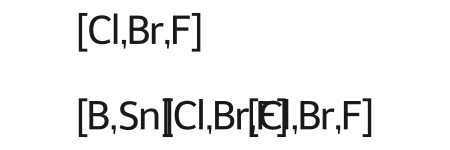

In [ ]:
mol=Chem.MolFromSmarts("[B,Sn].[Cl,Br,F].[Cl,Br,F].[Cl,Br,F]")
mol

In [ ]:
remov_pat=[
    # "[n1ccccc1]",
    # "[NX3,NX3H2,NX3H1]"
    # "[nH]1cnc[nH]1",    #0
    # "[Pd,Li,Al,Zn,Sn,Pt,Ni,Au]"
    # "[Pd]"
    ]
pattern=[     
    "[P].[Pd,Li,Al,Zn,Sn,Pt,Ni,Au]",    
    "[B,Sn,Al,Zn,Cu,Ag,Fe,Pt,Mg,Ti,Ca].[Cl,Br,F,I]"
    ]
match_set=set()
remove_mol=[Chem.MolFromSmarts(pat) for pat in remov_pat]
pattern_mol=[Chem.MolFromSmarts(pat) for pat in pattern]
def search_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    match=False
    for patmol in pattern_mol:
        if len(mol.GetSubstructMatches(patmol))>0:
            match=True
            break
    return match
def remove_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    remove=False
    for revmol in remove_mol:
        if len(mol.GetSubstructMatches(revmol))>0:
            remove=True
            break
    return remove

In [ ]:
smi="[Cl-].[Cl-].[Cl-].[Cl-].[Sn+4]"
mol=Chem.MolFromSmarts(smi)
# mol = Chem.AddHs(mol)
Chem.SanitizeMol(mol)            
params_3d = AllChem.ETKDGv2()
status_3d = AllChem.EmbedMolecule(mol, params_3d)
status_optim = AllChem.UFFOptimizeMolecule(mol, maxIters=100)

- 2. Cc1ccc(S(=O)(=O)O)cc1
- 结构：这是对甲苯磺酸（p-Toluenesulfonic acid，缩写为 TsOH），其中苯环上连有一个甲基（–CH₃）和磺酸基团（–SO₃H）。
- 性质：对甲苯磺酸是一个强酸，常用于酸催化反应。磺酸基使其具有很强的极性，且易溶于水和某些有机溶剂。
- 应用：它常被用作酸性催化剂、抗静电剂以及树脂和聚合物中的添加剂。
- 3. O=C(O)C(F)(F)F
- 结构：这是三氟乙酸（Trifluoroacetic acid, TFA），它是由羧酸基团（–COOH）和三氟甲基（–CF₃）组成的化合物。
- 性质：TFA 是一种强酸，常用于化学合成中的酸化和脱保护基团操作。三氟甲基基团使其具有较高的挥发性和疏水性。
- 应用：三氟乙酸通常作为溶剂或反应中的试剂，特别是在生物大分子合成和多肽合成中用于脱除保护基。

In [ ]:
columns=['Reactant1','Reactant2','Product','Additive','Solvent']
irxn=8
icol=3
col=columns[icol]
solv_col=columns[4]
search="Pd"
print(f"For Col:{col}")
# for j in range(1,9):
for j in range(4,5):    
    word_count=0
    pattern_count=0
    train_df=train_df_dict[j]
    for i in range(len(train_df)):
    # for i in range(100):    
        smiles=train_df.iloc[i][col]
        solv_smiles=train_df.iloc[i][solv_col]
        if search_pattern(smiles): 
            pattern_count+=1
            # print("    ",smiles)            
        else:
            pass
            print("    ",smiles)                        
            # print("    ",smiles, "\n    ",solv_smiles)
            # break
    print(f"For Reaction:{j} Searched for {search} count:{pattern_count}/{len(train_df)}")    
    # print(f"Searched for {search} count:{pattern_count}/{100}")
    # print(f"Searched for single P count:{pattern_count}/{word_count}")    

For Col:Additive
     O=C(O)[C@@H]1CCCN1.[BH4-].[Na+]
     C[Si](C)(C)OC(c1cc(C(F)(F)F)cc(C(F)(F)F)c1)(c1cc(C(F)(F)F)cc(C(F)(F)F)c1)[C@@H]1CCCN1
     Cc1ccc(S(=O)(=O)O)cc1
     CC(C)CCON=O
     Oc1ccc(O)cc1
     CC(=O)O.O
     C1CCNC1.O=S(=O)([O-])[O-].[Mg+2]
     C1CCNC1.O=S(=O)([O-])[O-].[Mg+2]
     [I-].[Na+]
     O=C(O)[C@@H]1CCCN1
     O=C(O)[C@@H]1CCCN1
     CC(C)(C)n1cc[n+](C(C)(C)C)c1.[Cl-].O=C([O-])[O-].[Cs+].[Cs+]
     C1CN2CCN1CC2
     CC(C)(C)[C@H](NC(=S)Nc1cc(C(F)(F)F)cc(C(F)(F)F)c1)C(=O)N[C@H](c1ccccc1)[C@@H](c1ccccc1)N1CCCCC1
     CC#N.CC#N.Cl[Pd]Cl.CCN(CC)CC.O=COc1ccccc1.c1cnc2c(c1)ccc1cccnc12
     [Li]CCCC
     Cc1cc(C(C)(C)C)c(O)c(C(C)(C)C)c1
     C[O-].[Li+].O=C(O)C(F)(F)F
     O=P1(O)Oc2c([Si](c3ccccc3)(c3ccccc3)c3ccccc3)cc3ccccc3c2-c2c(c([Si](c3ccccc3)(c3ccccc3)c3ccccc3)cc3ccccc23)O1
     C1COCCOCCOCCOCCOCCO1.O=C([O-])[O-].[Cs+].[Cs+]
     CC(=O)O.CN(C(=O)[C@@H](NC(=S)N[C@@H]1CCCC[C@H]1N)C(C)(C)C)C(c1ccccc1)c1ccccc1
     O=C1OI(=O)(O)c2ccccc21
     O=P1([O-])Oc2c(-

In [ ]:
count_dict

{'O=P([O-])([O-])O': 6,
 'CC[Al+2]': 53,
 '[Mg]': 2,
 '[Sc+3]': 6,
 'C[Al]': 6,
 'Oc1ccc2c(c1-c1c(O)ccc3c1CCCC3)CCCC2': 2,
 'C[N+](C)(C)C': 1,
 'C1CCC2=NCCCN2CC1': 20,
 'Br[Mg]c1ccccc1': 3,
 'CC(C)(C)[O-]': 14,
 'Cc1ccc(S(=O)(=O)[O-])cc1': 1,
 '[Na+]': 208,
 'C[Si](C)(C)OC(c1cc(C(F)(F)F)cc(C(F)(F)F)c1)(c1cc(C(F)(F)F)cc(C(F)(F)F)c1)[C@@H]1CCC[NH2+]1': 4,
 '[Al+3]': 136,
 'CCCO': 4,
 'C[C@@H](OC(C)(C)C)[C@H](NC(=O)OC(C)(C)C)C(=O)O': 1,
 'O=S([O-])[O-]': 2,
 'c1ccc(-c2ccccn2)nc1': 9,
 '[Cr+2]': 1,
 'CC1(C)CCCC(C)(C)[N-]1': 2,
 'O=C1c2ccccc2-c2ccccc21': 20,
 '[Li]C(C)CC': 2,
 'C[Al+2]': 24,
 'CN1C(=O)[C@H](Cc2c[nH]c3ccccc23)NC1(C)C': 1,
 'NC(N)=S': 3,
 'C[Si](C)(C)Cl': 2,
 'CC(C)OP(OC(C)C)OC(C)C': 2,
 '[Li+]': 132,
 'CC1(C)C2CCC1(CS(=O)(=O)O)C(=O)C2': 3,
 'C=C[C@H]1C[N@@]2CC[C@H]1C[C@H]2[C@@H](N)c1ccnc2ccccc12': 1,
 '[Ni]': 2,
 'CC(C)(C)OC(=O)N[C@@H](C(=O)O)c1ccccc1': 14,
 'CCCP1(=O)OP(=O)(CCC)OP(=O)(CCC)O1': 1,
 'OC(c1cccc(-c2cccc([C@@H](O)C34CC5CC(CC(C5)C3)C4)n2)n1)C12CC3CC(CC(C3)C1)C2':

In [ ]:
columns=['Reactant1','Reactant2','Product','Additive','Solvent']
irxn=4
icol=3
col=columns[icol]
solv_col=columns[4]
search="Pd"
print(f"For Col:{col}")
# rxn4_set=set()
count_dict={key:0 for key in rxn4_set}
# for j in range(1,9):
for j in range(4,5):    
    train_df=train_df_dict[j]
    for i in range(len(train_df)):
        smiles=train_df.iloc[i][col]
        for smi in smiles.split("."):
            count_dict[smi]+=1

For Col:Additive


### RXN 7

In [ ]:
remov_pat=[
    # "[n1ccccc1]",
    # "[NX3,NX3H2,NX3H1]"
    # "[nH]1cnc[nH]1",    #0
    # "[Pd,Li,Al,Zn,Sn,Pt,Ni,Au]"
    # "[Pd]"
    ]
pattern=[     
    "[P].[Pd,Li,Al,Zn,Sn,Pt,Ni,Au]",    
    "[B,Sn,Al,Zn,Cu,Ag,Fe,Pt,Mg,Ti,Ca].[Cl,Br,F,I]"
    ]
match_set=set()
remove_mol=[Chem.MolFromSmarts(pat) for pat in remov_pat]
pattern_mol=[Chem.MolFromSmarts(pat) for pat in pattern]
def search_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    match=False
    for patmol in pattern_mol:
        if len(mol.GetSubstructMatches(patmol))>0:
            match=True
            break
    return match
def remove_pattern(smiles):
    mol=Chem.MolFromSmiles(smiles)
    remove=False
    for revmol in remove_mol:
        if len(mol.GetSubstructMatches(revmol))>0:
            remove=True
            break
    return remove

In [ ]:
columns=['Reactant1','Reactant2','Product','Additive','Solvent']
icol=3
col=columns[icol]
solv_col=columns[4]
search="Pd"
print(f"For Col:{col}")
# for j in range(1,9):
for j in range(7,8):    
    word_count=0
    pattern_count=0
    train_df=train_df_dict[j]
    for i in range(len(train_df)):
    # for i in range(100):    
        smiles=train_df.iloc[i][col]
        solv_smiles=train_df.iloc[i][solv_col]
        if search_pattern(smiles): 
            pattern_count+=1
            # print("    ",smiles)            
        else:
            pass
            print("    ",smiles)                        
            # print("    ",smiles, "\n    ",solv_smiles)
            # break
    print(f"For Reaction:{j} Searched for {search} count:{pattern_count}/{len(train_df)}")    
    # print(f"Searched for {search} count:{pattern_count}/{100}")
    # print(f"Searched for single P count:{pattern_count}/{word_count}")    

For Col:Additive
     II
     O=C(O)c1ccccc1
     [F-].[K+]
     O=C(NS(=O)(=O)C(F)(F)F)[C@@H]1CCCN1
     CC1(C)CCCC(C)(C)N1
     C1CN=C2NCCCN2C1
     CC[O-].[Na+]
     C=C[C@H]1C[N@@]2CC[C@H]1C[C@H]2C(NC(=S)Nc1cc(C(F)(F)F)cc(C(F)(F)F)c1)c1ccnc2ccc(OC)cc12
     C=C[C@H]1C[N@@]2CC[C@H]1C[C@@H]2C(NC(=S)Nc1cc(C(F)(F)F)cc(C(F)(F)F)c1)c1ccnc2ccccc12
     CCN(CC)CC
     [Cl-].[Cl-].[Cl-].[In+3]
     C1CCNCC1
     C=C[C@H]1C[N@]2CCC1CC2C(Nc1c(Nc2cc(C(F)(F)F)cc(C(F)(F)F)c2)c(=O)c1=O)c1ccnc2ccc(OC)cc12
     CC[C@H]1C[N+]2(Cc3c4ccccc4cc4ccccc34)CC[C@H]1C[C@H]2[C@H](OCc1ccccc1)c1ccnc2ccccc12.[Br-].Cc1cc(C)c(O)c(C)c1.[K+].[OH-]
     C[Si](C)(C)OC(c1cc(C(F)(F)F)cc(C(F)(F)F)c1)(c1cc(C(F)(F)F)cc(C(F)(F)F)c1)[C@@H]1CCCN1
     [Cl-].[Li+].[Li]CCCC
     [Bi+3].[Cl-].[Cl-].[Cl-]
     CC(C)[N-]C(C)C.[Li+]
     CO[B-](OC)(OC)OC.[Na+]
     C=C[C@H]1CN2CC[C@H]1C[C@H]2[C@@H](Nc1c(NCc2cc(C(F)(F)F)cc(C(F)(F)F)c2)c(=O)c1=O)c1ccnc2ccc(OC)cc12.[Cl-].[Na+]
     C[Si](C)(C)OC(c1ccccc1)(c1ccccc1)[C@@H]1CCCN1
     O=C

### RXN8

In [ ]:
columns=['Reactant1','Reactant2','Product','Additive','Solvent']
icol=3
col=columns[icol]
solv_col=columns[4]
search="Pd"
print(f"For Col:{col}")
# for j in range(1,9):
for j in range(8,9):    
    word_count=0
    pattern_count=0
    train_df=train_df_dict[j]
    for i in range(len(train_df)):
    # for i in range(100):    
        smiles=train_df.iloc[i][col]
        solv_smiles=train_df.iloc[i][solv_col]
        if search_pattern(smiles): 
            pattern_count+=1
            # print("    ",smiles)            
        else:
            pass
            print("    ",smiles)                        
            # print("    ",smiles, "\n    ",solv_smiles)
            # break
    print(f"For Reaction:{j} Searched for {search} count:{pattern_count}/{len(train_df)}")    
    # print(f"Searched for {search} count:{pattern_count}/{100}")
    # print(f"Searched for single P count:{pattern_count}/{word_count}")    

For Col:Additive
     CCN(CC)c1ccccc1
     O=C([O-])[O-].[K+].[K+]
     CCN(CC)CC
     CCN(CC)CC
     CCN(C(C)C)C(C)C.CN(C)CCN
     CCN=C=NCCCN(C)C.Cl.On1nnc2ccccc21
     CCOC(=O)N1c2ccccc2C=CC1OCC
     CCN(CC)CC
     CCN=C=NCCCN(C)C.Cl.CN1CCOCC1.On1nnc2cccnc21
     CCN(CC)CC
     O=C(n1ccnc1)n1ccnc1
     CCN(C(C)C)C(C)C.CCOC(=O)C(C#N)=NOC(=C[NH2+]C)N1CCOCC1.F[P-](F)(F)(F)(F)F
     CCN(CC)CC
     [Na+].[OH-]
     CCN(CC)CC
     CCN(CC)CC.CN(C)C(=[O+]n1nnc2ccccc21)N(C)C.F[P-](F)(F)(F)(F)F
     CN(C)C(Cl)=[N+](C)C.F[P-](F)(F)(F)(F)F.Cn1ccnc1
     CCN(C(C)C)C(C)C
     CCN(CC)CC
     CCN(C(C)C)C(C)C
     CCN=C=NCCCN(C)C.Cl.CN1CCOCC1.On1nnc2ccccc21
     O=C([O-])[O-].[Na+].[Na+]
     CCN=C=NCCCN(C)C.Cl.On1nnc2ccccc21
     c1ccncc1
     CCN(CC)CC
     CCN(C(C)C)C(C)C.CN(C)C(n1n[n+]([O-])c2ncccc21)=[N+](C)C.F[P-](F)(F)(F)(F)F
     COc1nc(OC)nc([N+]2(C)CCOCC2)n1.[Cl-]
     CCN=C=NCCCN(C)C.Cl.On1nnc2ccccc21
     CCN(CC)CC
     CCN=C=NCCCN(C)C.Cl.On1nnc2ccccc21
     CCN(C(C)C)C(C)C.CN(C)C(n1n[n+